In [1]:
from PIL import Image, ImageDraw
import numpy as np
from matplotlib.font_manager import font_family_aliases


def patch_and_merge_with_grid(image_path, output_filename="output.png", gap=10):
    # Load and resize the image to 224x224 pixels
    image = Image.open(image_path).resize((224, 224))
    img_array = np.array(image)

    # Get image dimensions
    H, W = img_array.shape[:2]
    patch_size = 2
    patch_height = H // patch_size
    patch_width = W // patch_size

    # Extract four patches and store them
    patches = []
    for i in range(patch_size):
        for j in range(patch_size):
            patch = img_array[i*patch_height:(i+1)*patch_height, j*patch_width:(j+1)*patch_width]
            patch_img = Image.fromarray(patch)

            # Draw 4x4 grey grid lines on each patch
            draw = ImageDraw.Draw(patch_img)
            grid_size = 4
            for k in range(grid_size + 1):
                pos_y = int(round(k * patch_height / grid_size))
                draw.line([(0, pos_y), (patch_width-1, pos_y)], fill=(128,128,128), width=1)
                pos_x = int(round(k * patch_width / grid_size))
                draw.line([(pos_x, 0), (pos_x, patch_height-1)], fill=(128,128,128), width=1)
            patches.append(patch_img)

    # Create a canvas with a white background, including space for the gap
    canvas_width = 2 * patch_width + gap
    canvas_height = 2 * patch_height + gap
    canvas = Image.new("RGB", (canvas_width, canvas_height), (255,255,255))

    # Paste the four patches onto the canvas with gaps
    canvas.paste(patches[0], (0, 0))
    canvas.paste(patches[1], (patch_width + gap, 0))
    canvas.paste(patches[2], (0, patch_height + gap))
    canvas.paste(patches[3], (patch_width + gap, patch_height + gap))

    # Save the final image
    canvas.save(output_filename)

# Example usage
patch_and_merge_with_grid("dataset/tomato_leaf_dataset/train/Bacterial_spot/0a64655c-4052-4e5f-a696-2a6cf25d10c9___GCREC_Bact.Sp 6017.JPG", "outputs_plots/patched_2.png", gap=10)

In [5]:
from PIL import Image, ImageDraw
import numpy as np
import os
import logging

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def create_patches_with_grid(image_path, output_folder="patches", patch_size=4, grid_size=4, gap=10):
    try:
        # Verify image path exists
        if not os.path.exists(image_path):
            logging.error(f"Image path does not exist: {image_path}")
            raise FileNotFoundError(f"Image file not found: {image_path}")

        # Create output folder if it doesn't exist
        try:
            os.makedirs(output_folder, exist_ok=True)
            logging.info(f"Output folder created or exists: {output_folder}")
        except Exception as e:
            logging.error(f"Failed to create output folder {output_folder}: {e}")
            raise

        # Load and resize the image to 224x224 pixels
        try:
            image = Image.open(image_path).resize((224, 224))
            logging.info(f"Image loaded and resized: {image_path}")
        except Exception as e:
            logging.error(f"Failed to load or resize image {image_path}: {e}")
            raise

        img_array = np.array(image)

        # Get image dimensions
        H, W = img_array.shape[:2]
        patch_height = H // patch_size
        patch_width = W // patch_size
        logging.info(f"Image dimensions: {H}x{W}, Patch size: {patch_height}x{patch_width}")

        # Extract 16 patches and process each
        for i in range(patch_size):
            for j in range(patch_size):
                # Extract patch
                patch = img_array[i*patch_height:(i+1)*patch_height, j*patch_width:(j+1)*patch_width]
                patch_img = Image.fromarray(patch)

                # Draw 4x4 grey grid lines on the patch
                draw = ImageDraw.Draw(patch_img)
                for k in range(grid_size + 1):
                    pos_y = int(round(k * patch_height / grid_size))
                    draw.line([(0, pos_y), (patch_width-1, pos_y)], fill=(128,128,128), width=1)
                    pos_x = int(round(k * patch_width / grid_size))
                    draw.line([(pos_x, 0), (pos_x, patch_height-1)], fill=(128,128,128), width=1)

                # Save the patch as a separate image
                patch_filename = os.path.join(output_folder, f"patch_{i}_{j}.png")
                try:
                    patch_img.save(patch_filename)
                    logging.info(f"Saved patch: {patch_filename}")
                except Exception as e:
                    logging.error(f"Failed to save patch {patch_filename}: {e}")
                    raise

        logging.info("All patches created successfully")

    except Exception as e:
        logging.error(f"An error occurred: {e}")
        raise

# Example usage
if __name__ == "__main__":
    try:
        create_patches_with_grid(
            "dataset/tomato_leaf_dataset/train/Bacterial_spot/0a64655c-4052-4e5f-a696-2a6cf25d10c9___GCREC_Bact.Sp 6017.JPG",
            output_folder="outputs_plots/patches_16",
            patch_size=4,
            grid_size=4,
            gap=10
        )
    except Exception as e:
        logging.error(f"Failed to execute create_patches_with_grid: {e}")

2025-05-04 11:04:11,457 - INFO - Output folder created or exists: outputs_plots/patches_16
2025-05-04 11:04:11,460 - INFO - Image loaded and resized: dataset/tomato_leaf_dataset/train/Bacterial_spot/0a64655c-4052-4e5f-a696-2a6cf25d10c9___GCREC_Bact.Sp 6017.JPG
2025-05-04 11:04:11,461 - INFO - Image dimensions: 224x224, Patch size: 56x56
2025-05-04 11:04:11,465 - INFO - Saved patch: outputs_plots/patches_16\patch_0_0.png
2025-05-04 11:04:11,467 - INFO - Saved patch: outputs_plots/patches_16\patch_0_1.png
2025-05-04 11:04:11,471 - INFO - Saved patch: outputs_plots/patches_16\patch_0_2.png
2025-05-04 11:04:11,474 - INFO - Saved patch: outputs_plots/patches_16\patch_0_3.png
2025-05-04 11:04:11,476 - INFO - Saved patch: outputs_plots/patches_16\patch_1_0.png
2025-05-04 11:04:11,479 - INFO - Saved patch: outputs_plots/patches_16\patch_1_1.png
2025-05-04 11:04:11,481 - INFO - Saved patch: outputs_plots/patches_16\patch_1_2.png
2025-05-04 11:04:11,484 - INFO - Saved patch: outputs_plots/patche

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from io import BytesIO

# Define new class names as letters A to K
new_class_names = list('ABCDEFGHIJK')

def read_confusion_matrix_csv(file_path, new_class_names):
    """
    Read a confusion matrix from a CSV file and map original class names to new_class_names (A to K).
    Returns a numpy array of the confusion matrix normalized to percentages.
    """
    df = pd.read_csv(file_path)

    # Ensure the True Label column is the index
    if 'True Label' in df.columns:
        df.set_index('True Label', inplace=True)

    # Get original class names from the CSV
    original_class_names = df.index.tolist()
    if len(original_class_names) != len(new_class_names):
        raise ValueError(f"Number of classes in CSV ({len(original_class_names)}) does not match expected number ({len(new_class_names)})")

    # Create a mapping from original class names to new class names (A to K)
    class_mapping = {old: new for old, new in zip(original_class_names, new_class_names)}

    # Rename index and columns to new class names
    df.index = df.index.map(class_mapping)
    df.columns = df.columns.map(class_mapping)

    # Verify that all new class names are present
    if not all(col in df.columns for col in new_class_names) or not all(row in df.index for row in new_class_names):
        raise ValueError(f"CSV file {file_path} does not match expected class names after mapping")

    # Convert to numpy array, ensuring order matches new_class_names
    cm = df.loc[new_class_names, new_class_names].to_numpy()

    # Normalize to percentages (sum to 100% per row)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # Avoid division by zero
    cm = (cm / row_sums) * 100
    return cm

def plot_confusion_matrices(cms, titles, class_names, output_dir, plot_name='separate_confusion_matrices.pdf'):
    """
    Plot three confusion matrices in a single row using seaborn heatmap with one colorbar and save as PDF using Pillow.
    """
    fig, axes = plt.subplots(1, 3, figsize=(36, 10), dpi=300)
    axes = axes.flatten()

    for idx, (cm, title) in enumerate(zip(cms, titles)):
        sns.heatmap(
            cm,
            annot=True,
            fmt=".2f",
            cmap="Greens",
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={"size": 14},
            cbar=(idx == 2),  # Only show colorbar for the last subplot
            square=True,
            ax=axes[idx]
        )
        axes[idx].set_xlabel("Predicted Labels", fontsize=64, fontweight="bold",)
        axes[idx].set_ylabel("True Labels", fontsize=64,fontweight="bold")
        axes[idx].set_title(title, fontsize=64, pad=20,fontweight="bold")
        axes[idx].tick_params(axis='x', rotation=45, labelright=True, labelsize=24)
        axes[idx].tick_params(axis='y', rotation=0, labelsize=24)
        # Make x and y tick labels bold
        for label in axes[idx].get_xticklabels() + axes[idx].get_yticklabels():
            label.set_weight('bold')

    plt.tight_layout()

    # Save the plot to a BytesIO buffer as PNG
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=300, bbox_inches='tight')
    plt.close()
    buf.seek(0)

    # Use Pillow to convert PNG to PDF
    image = Image.open(buf)
    if image.mode != 'RGB':
        image = image.convert('RGB')

    # Save as PDF
    plot_path = os.path.join(output_dir, 'plots', plot_name)
    os.makedirs(os.path.dirname(plot_path), exist_ok=True)
    image.save(plot_path, 'PDF', quality=95, resolution=300)
    print(f"Saved confusion matrices plot to {plot_path}")
    buf.close()

def main():
    input_dir = 'outputs_test/summaries'  # Directory containing CSV files
    output_dir = 'outputs_dataset/plots'  # Directory to save the plot
    csv_files = [
        os.path.join(input_dir, 'confusion_matrix_swin_small.csv'),
        os.path.join(input_dir, 'confusion_matrix_convnext_small.csv'),
        os.path.join(input_dir, 'confusion_matrix_efficientvit_b0.csv')
    ]
    titles = [
        "Swin Small",
        "Convnext Small",
        "EfficientVit B0"
    ]

    try:
        # Verify all CSV files exist
        for csv_file in csv_files:
            if not os.path.exists(csv_file):
                raise FileNotFoundError(f"CSV file {csv_file} does not exist")

        # Read and normalize confusion matrices, mapping original class names to A-K
        cms = [read_confusion_matrix_csv(csv_file, new_class_names) for csv_file in csv_files]

        # Plot and save the confusion matrices
        plot_confusion_matrices(cms, titles, new_class_names, output_dir)

    except Exception as e:
        print(f"Error: {e}")

if __name__ == '__main__':
    main()

Saved confusion matrices plot to outputs_dataset/plots\plots\separate_confusion_matrices.pdf


In [3]:
import timm
from ptflops import get_model_complexity_info
import csv

# Model names used in your paper
model_names = [
    "vit_tiny_patch16_224",
    "vit_small_patch16_224",
    "vit_base_patch16_224",
    "mobilevit_xxs",
    "mobilevit_xs",
    "mobilevit_s",
    "efficientvit_b0",
    "efficientvit_m5",
    "efficientvit_b2",
    "swin_tiny_patch4_window7_224",
    "swin_small_patch4_window7_224",
    "swin_base_patch4_window7_224",
    "convnext_tiny",
    "convnext_small",
]

input_shape = (3, 224, 224)

# Output CSV file
output_file = "model_complexity_results.csv"

# Print and write header
print(f"{'Model':35s} {'Params (M)':>12s} {'FLOPs (G)':>12s}")
print("-" * 60)

# Open CSV file for writing
with open(output_file, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["Model", "Params (M)", "FLOPs (G)"])  # Header

    for model_name in model_names:
        try:
            model = timm.create_model(model_name, pretrained=False)
            macs, params = get_model_complexity_info(
                model, input_shape, as_strings=False, print_per_layer_stat=False
            )
            params_m = params / 1e6
            flops_g = macs / 1e9
            print(f"{model_name:35s} {params_m:12.2f} {flops_g:12.2f}")
            writer.writerow([model_name, f"{params_m:.2f}", f"{flops_g:.2f}"])
        except Exception as e:
            print(f"{model_name:35s} ERROR - {e}")
            writer.writerow([model_name, "ERROR", str(e)])


Model                                 Params (M)    FLOPs (G)
------------------------------------------------------------
vit_tiny_patch16_224                        5.72         0.91
vit_small_patch16_224                      22.05         3.22
vit_base_patch16_224                       86.57        12.02
mobilevit_xxs                               1.27         0.25
mobilevit_xs                                2.32         0.66
mobilevit_s                                 5.58         1.25
efficientvit_b0                             3.41         0.10
efficientvit_m5                            12.47         0.52
efficientvit_b2                            24.33         1.57
swin_tiny_patch4_window7_224               28.29         4.38
swin_small_patch4_window7_224              49.61         8.56
swin_base_patch4_window7_224               87.77        15.19
convnext_tiny                              28.59         4.48
convnext_small                             50.22         8.72


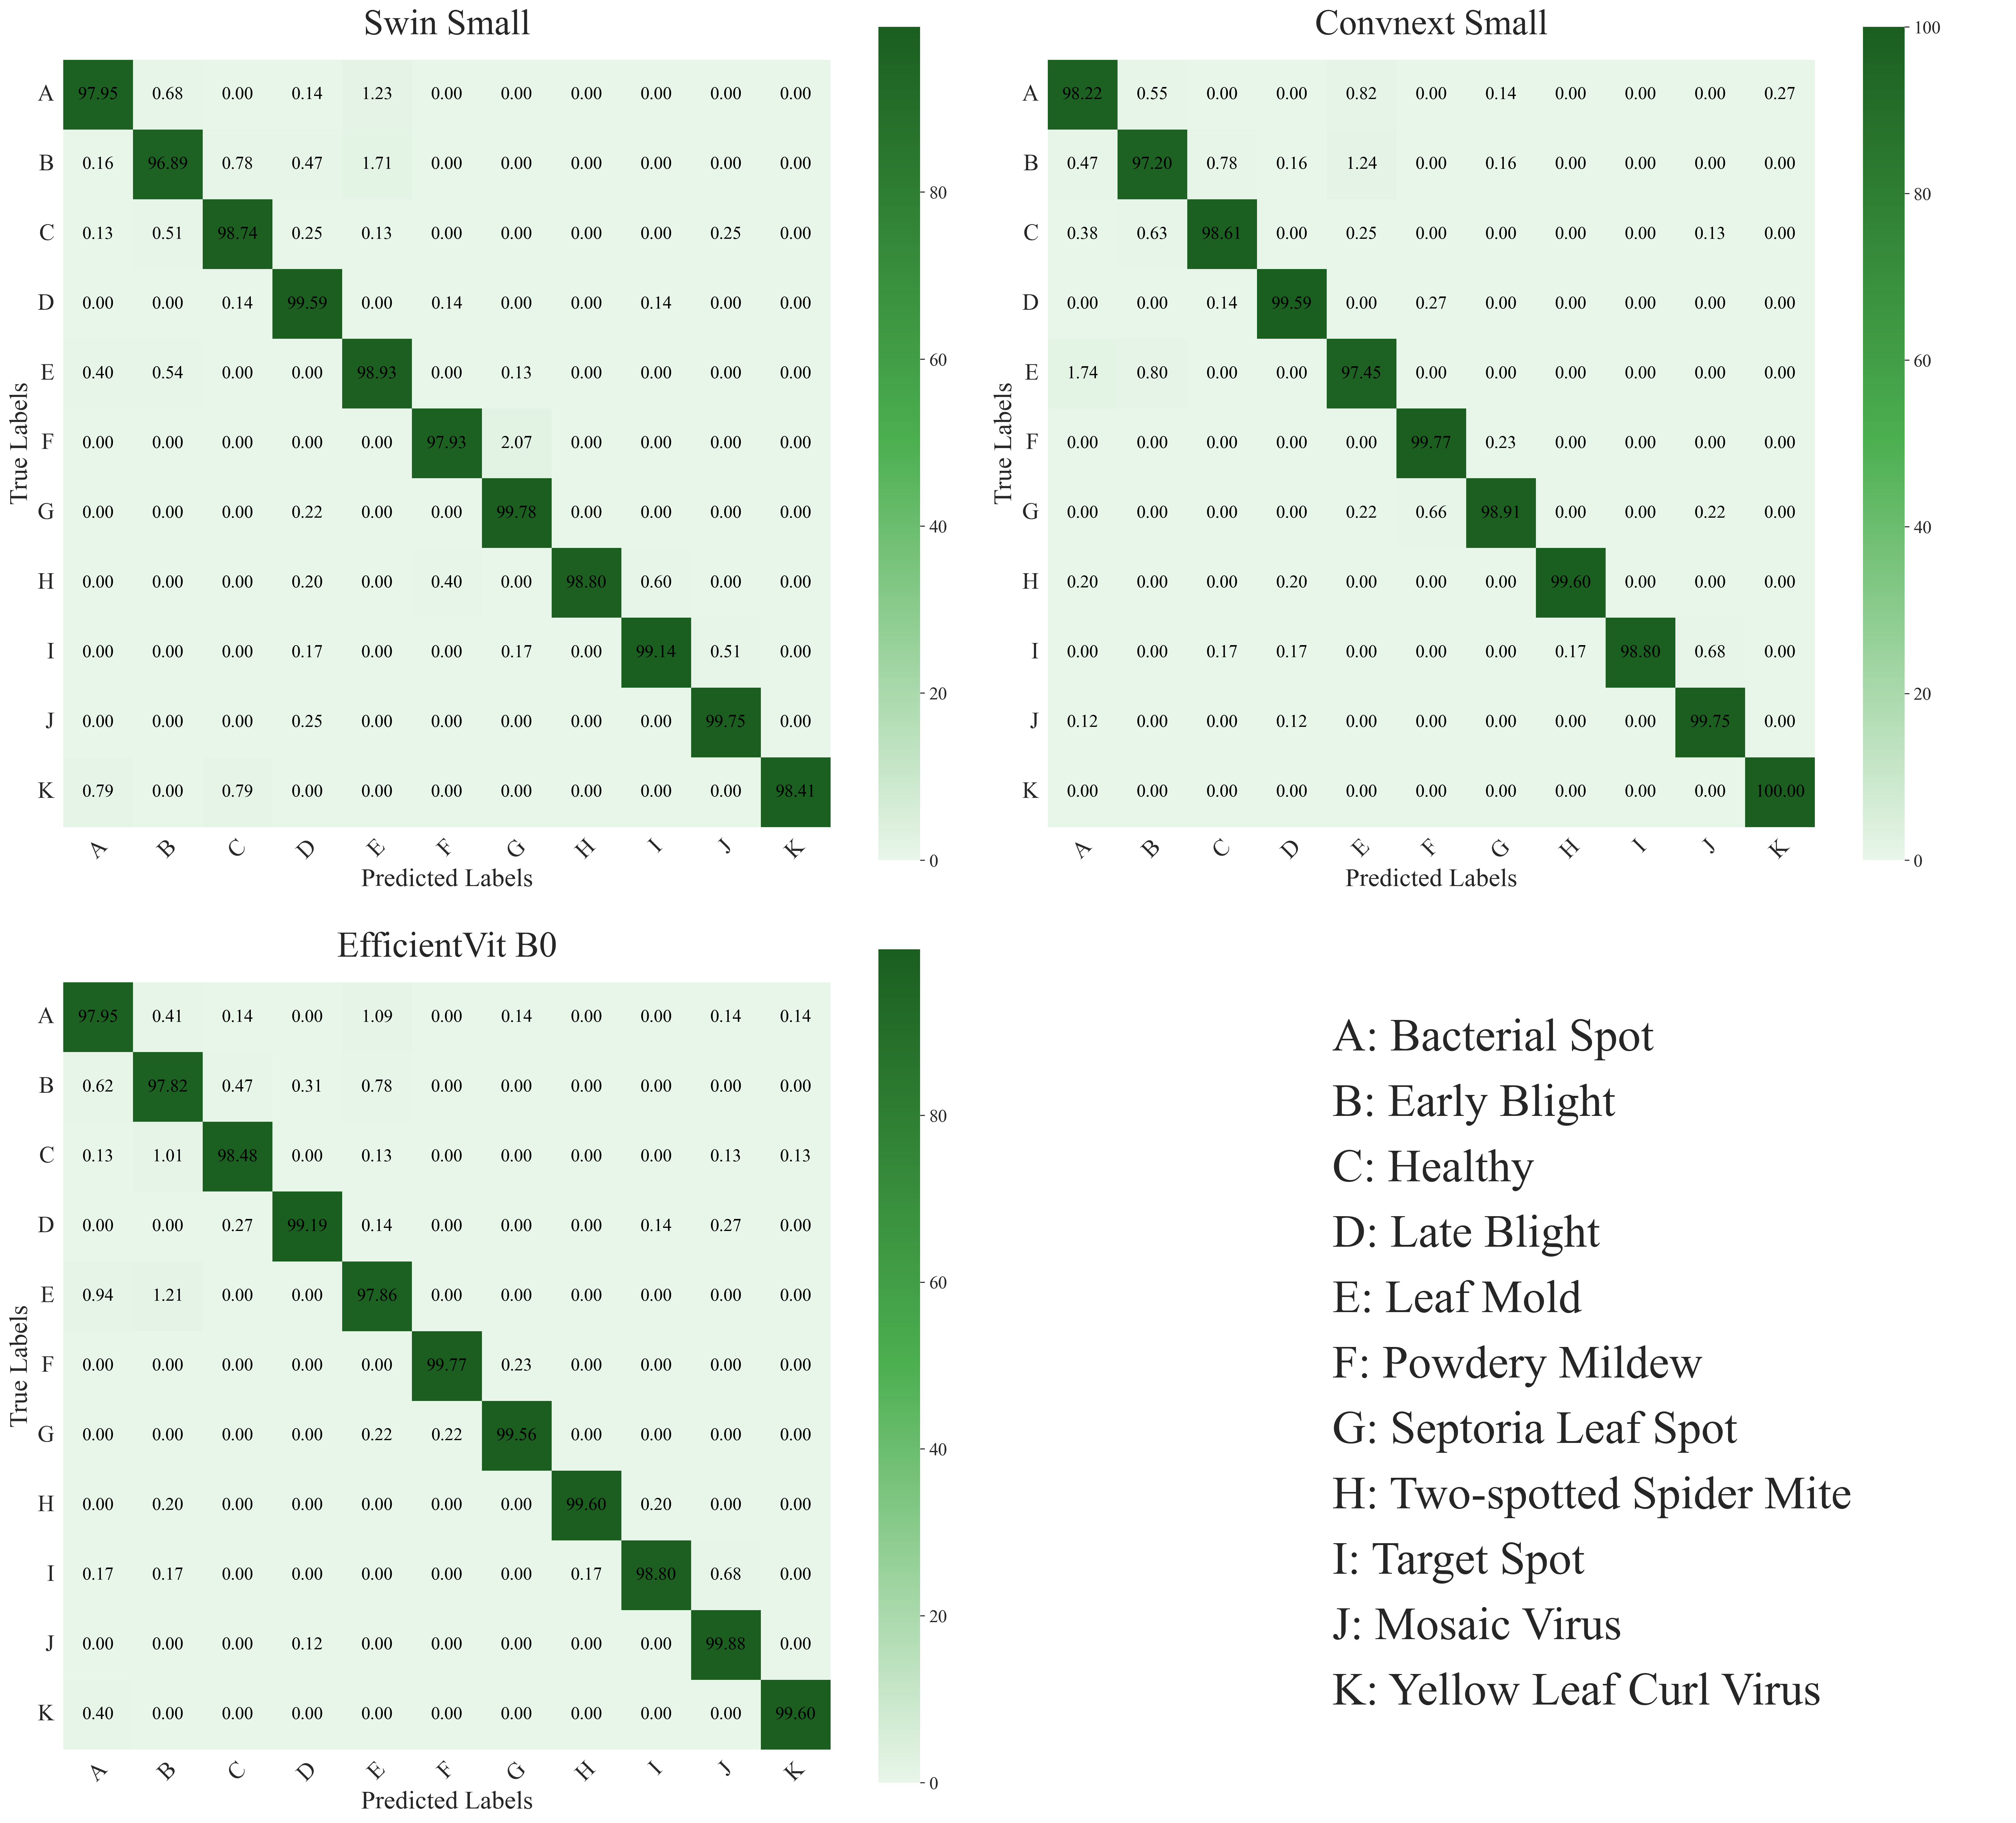

Saved confusion matrices PDF to outputs_dataset\plots\confusion_matrices_2x2.pdf


In [23]:
import os
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages

# Define modified class names for legend
class_names = [
    "Bacterial Spot",
    "Early Blight",
    "Healthy",
    "Late Blight",
    "Leaf Mold",
    "Powdery Mildew",
    "Septoria Leaf Spot",
    "Two-spotted Spider Mite",
    "Target Spot",
    "Mosaic Virus",
    "Yellow Leaf Curl Virus"
]

# Single-letter labels for axes (A to K for 11 classes)
letter_labels = list('ABCDEFGHIJK')

# Original class names (as expected in CSV files)
original_class_names = [
    "Bacterial_spot",
    "Early_blight",
    "healthy",
    "Late_blight",
    "Leaf_Mold",
    "powdery_mildew",
    "Septoria_leaf_spot",
    "Spider_mites Two-spotted_spider_mite",
    "Target_Spot",
    "Tomato_mosaic_virus",
    "Tomato_Yellow_Leaf_Curl_Virus"
]

def read_confusion_matrix_csv(file_path):
    try:
        df = pd.read_csv(file_path)
        # Ensure the True Label column is the index
        if 'True Label' in df.columns:
            df.set_index('True Label', inplace=True)
        # Verify that columns and index match original_class_names
        if not all(col in df.columns for col in original_class_names) or not all(row in df.index for row in original_class_names):
            raise ValueError(f"CSV file {file_path} does not match expected class names: {original_class_names}")
        # Convert to numpy array, ensuring order matches original_class_names
        cm = df.loc[original_class_names, original_class_names].to_numpy()
        # Normalize to percentages (sum to 100% per row)
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1  # Avoid division by zero
        cm = (cm / row_sums) * 100
        return cm
    except Exception as e:
        raise ValueError(f"Error reading {file_path}: {e}")

def plot_confusion_matrices(cms, titles, class_names, letter_labels, output_dir, plot_name='confusion_matrices_2x2.pdf'):
    # Define custom green colormap
    colors = ['#E8F5E9', '#4CAF50', '#1B5E20']  # Light green to dark green
    cmap = LinearSegmentedColormap.from_list('CustomGreens', colors)

    # Create 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(22, 20), dpi=300)
    axes = axes.flatten()

    # Plot three confusion matrices
    for idx, (cm, title) in enumerate(zip(cms, titles)):
        sns.heatmap(
            cm,
            annot=True,
            fmt=".2f",
            cmap=cmap,
            xticklabels=letter_labels,
            yticklabels=letter_labels,
            annot_kws={"size": 14, "color": "black"},
            cbar=True,
            square=True,
            ax=axes[idx]
        )
        axes[idx].set_xlabel("Predicted Labels", fontsize=20, fontfamily='Times New Roman')
        axes[idx].set_ylabel("True Labels", fontsize=20, fontfamily='Times New Roman')
        axes[idx].set_title(title, fontsize=28, pad=20, fontfamily='Times New Roman')
        axes[idx].tick_params(axis='x', rotation=45, labelsize=18)
        axes[idx].tick_params(axis='y', rotation=0, labelsize=18)

    # Create legend in the fourth subplot (bottom-right)
    axes[3].axis('off')
    legend_patches = [mpatches.Patch(color='white', label=f"{letter}: {name}") for letter, name in zip(letter_labels, class_names)]
    axes[3].legend(
        handles=legend_patches,
        title="",
        fontsize=40,
        loc='center',
        bbox_to_anchor=(0.5, 0.5),
        frameon=False,
        prop={'family': 'Times New Roman', 'size': 36},
        title_fontproperties={'family': 'Times New Roman', 'size': 22}
    )
    # axes[3].set_title("Legend", fontsize=36, pad=20, fontfamily='Times New Roman')

    plt.tight_layout()

    # ✅ Show plot before saving (for visual check)
    plt.show()

    # ✅ Save high-quality PDF to buffer
    buffer = io.BytesIO()
    fig.canvas.draw()  # Ensure everything is rendered

    os.makedirs(os.path.join(output_dir, 'plots'), exist_ok=True)
    plot_path = os.path.join(output_dir, 'plots', plot_name)

    with PdfPages(buffer) as pdf:
        pdf.savefig(fig, bbox_inches='tight')

    with open(plot_path, 'wb') as f:
        f.write(buffer.getvalue())

    print(f"Saved confusion matrices PDF to {plot_path}")
    buffer.close()
    plt.close(fig)

def main():
    input_dir = 'outputs_test/summaries'
    output_dir = 'outputs_dataset'
    csv_files = [
        os.path.join(input_dir, 'confusion_matrix_swin_small.csv'),
        os.path.join(input_dir, 'confusion_matrix_convnext_small.csv'),
        os.path.join(input_dir, 'confusion_matrix_efficientvit_b0.csv')
    ]
    titles = [
        "Swin Small",
        "Convnext Small",
        "EfficientVit B0"
    ]

    try:
        for csv_file in csv_files:
            if not os.path.exists(csv_file):
                raise FileNotFoundError(f"CSV file {csv_file} does not exist")

        cms = [read_confusion_matrix_csv(csv_file) for csv_file in csv_files]
        plot_confusion_matrices(cms, titles, class_names, letter_labels, output_dir)

    except Exception as e:
        print(f"Error: {e}")

if __name__ == '__main__':
    main()


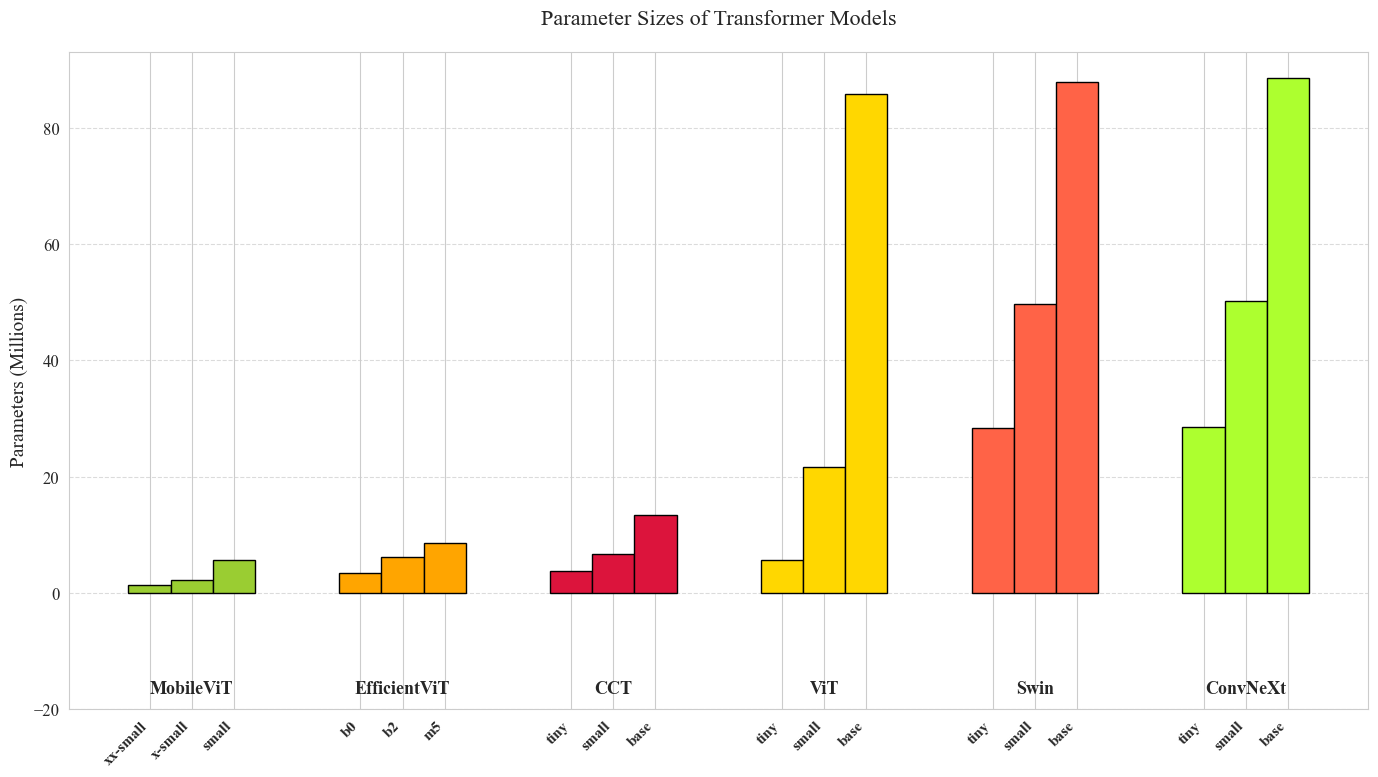

Saved plot to outputs_dataset/plots\parameter_counts.pdf

Model Parameter Sizes (in Millions):
MobileViT:
  xx-small: 1.29M
  x-small: 2.29M
  small: 5.58M
EfficientViT:
  b0: 3.40M
  b2: 6.10M
  m5: 8.50M
CCT:
  tiny: 3.70M
  small: 6.70M
  base: 13.40M
ViT:
  tiny: 5.70M
  small: 21.70M
  base: 85.80M
Swin:
  tiny: 28.30M
  small: 49.60M
  base: 87.80M
ConvNeXt:
  tiny: 28.60M
  small: 50.20M
  base: 88.60M


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import os
from io import BytesIO
from PIL import Image

def plot_model_parameter_sizes(include_optional_models=True):
    # Increase Pillow's image size limit to avoid DecompressionBombWarning
    Image.MAX_IMAGE_PIXELS = 200000000

    models = [
        {
            'type': 'MobileViT',
            'color': '#9ACD32',  # YellowGreen
            'variants': [
                ('xx_small', 1.29),
                ('x_small', 2.29),
                ('small', 5.58)
            ]
        },
        {
            'type': 'Swin',
            'color': '#FF6347',  # Tomato red
            'variants': [
                ('tiny', 28.3),
                ('small', 49.6),
                ('base', 87.8)
            ]
        },
        {
            'type': 'ViT',
            'color': '#FFD700',  # Gold (yellow)
            'variants': [
                ('tiny', 5.7),
                ('small', 21.7),
                ('base', 85.8)
            ]
        },
        {
            'type': 'ConvNeXt',
            'color': '#ADFF2F',  # GreenYellow
            'variants': [
                ('tiny', 28.6),
                ('small', 50.2),
                ('base', 88.6)
            ]
        }
    ]

    if include_optional_models:
        models.extend([
            {
                'type': 'CCT',
                'color': '#DC143C',  # Crimson
                'variants': [
                    ('tiny', 3.7),
                    ('small', 6.7),
                    ('base', 13.4),
                ]
            },
            {
                'type': 'EfficientViT',
                'color': '#FFA500',  # Orange
                'variants': [
                    ('b0', 3.4),
                    ('b2', 6.1),
                    ('m5', 8.5)
                ]
            },
        ])

    models.sort(key=lambda m: m['variants'][0][1])
    # Sort variants within each model by parameter size
    for model in models:
        model['variants'].sort(key=lambda x: x[1])

    model_names = []
    param_sizes = []
    colors = []
    positions = []
    group_positions = []
    current_pos = 0
    bar_width = 0.15
    group_gap = 0.3  # Reduced from 0.6 to tighten spacing

    xtick_labels = []

    for model in models:
        num_variants = len(model['variants'])
        start_pos = current_pos + bar_width * num_variants / 2.0 - bar_width / 2.0
        group_positions.append(start_pos)
        for variant, params in model['variants']:
            model_names.append(model['type'])
            xtick_labels.append(variant.replace('_', '-'))
            param_sizes.append(params)
            colors.append(model['color'])
            positions.append(current_pos)
            current_pos += bar_width
        current_pos += group_gap

    plt.figure(figsize=(14, 8))
    bars = plt.bar(positions, param_sizes, width=bar_width, color=colors, edgecolor='black')

    plt.title('Parameter Sizes of Transformer Models', fontsize=16, pad=20)
    plt.ylabel('Parameters (Millions)', fontsize=14)
    plt.xticks(positions, xtick_labels, rotation=45, ha='right', fontsize=11, fontweight='bold')
    plt.yticks(fontsize=12)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

    # Add model group names below the x-axis
    y_min, y_max = plt.ylim()
    y_offset = y_min - 15  # Ensure visibility
    for group_pos, model in zip(group_positions, models):
        plt.text(group_pos, y_offset, model['type'],
                 ha='center', va='top', fontsize=13, fontweight='bold')

    # Adjust y-axis to accommodate model names
    plt.ylim(y_min - 20, y_max)

    plt.tight_layout()

    # Save plot to a BytesIO buffer as PNG
    buf = BytesIO()
    output_dir = 'outputs_dataset/plots'
    os.makedirs(output_dir, exist_ok=True)

    plt.savefig(buf, format='png', dpi=600, bbox_inches='tight', pad_inches=0)
    plt.show()
    buf.seek(0)

    # Use Pillow to convert PNG to PDF
    img = Image.open(buf)
    plot_path = os.path.join(output_dir, 'parameter_counts.pdf')
    img.save(plot_path, format='PDF', resolution=600)

    # Clean up
    buf.close()
    plt.close()
    print(f"Saved plot to {plot_path}")

    print("\nModel Parameter Sizes (in Millions):")
    for model in models:
        print(f"{model['type']}:")
        for variant, params in model['variants']:
            print(f"  {variant.replace('_', '-')}: {params:.2f}M")

if __name__ == "__main__":
    plot_model_parameter_sizes(include_optional_models=True)


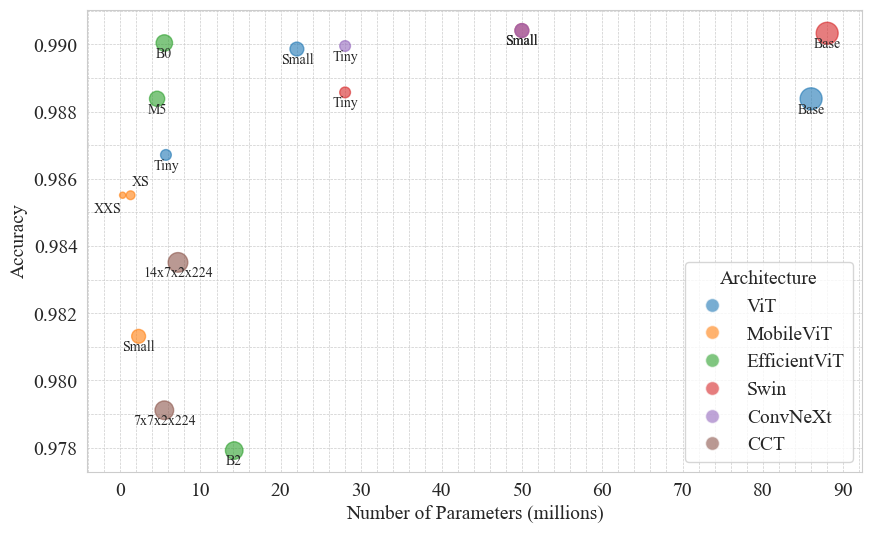

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
import io

# Set Seaborn style
sns.set_style("whitegrid")

# Set global font to Times New Roman and remove bolding
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.weight': 'normal',
    'axes.labelweight': 'normal',
    'axes.titleweight': 'normal',
    'legend.title_fontsize': 'medium',
    'legend.fontsize': 'medium'
})

# Data
models = [
    "ViT-Tiny", "ViT-Small", "ViT-Base",
    "MobileViT-XXSmall", "MobileViT-XSmall", "MobileViT-Small",
    "EfficientViT-M5", "EfficientViT-B0", "EfficientViT-B2",
    "Swin-Tiny", "Swin-Small", "Swin-Base",
    "ConvNeXt-Tiny", "ConvNeXt-Small",
    "CCT-7x7x2x224", "CCT-14x7x2x224"
]
params = [5.7, 22, 86, 0.31, 1.3, 2.3, 4.6, 5.5, 14.2, 28, 50, 88, 28, 50, 5.5, 7.2]
accuracies = [
    0.986710, 0.98986, 0.98838,
    0.985511, 0.985511, 0.981314,
    0.98838, 0.99004, 0.977916,
    0.98857, 0.99041, 0.99033,
    0.98995, 0.99041,
    0.979115, 0.983513
]

# Architecture groups and colors
architectures = [
    "ViT", "ViT", "ViT",
    "MobileViT", "MobileViT", "MobileViT",
    "EfficientViT", "EfficientViT", "EfficientViT",
    "Swin", "Swin", "Swin",
    "ConvNeXt", "ConvNeXt",
    "CCT", "CCT"
]
unique_archs = ["ViT", "MobileViT", "EfficientViT", "Swin", "ConvNeXt", "CCT"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
arch_to_color = dict(zip(unique_archs, colors))

# Size labels
size_labels = []
for model in models:
    if "Tiny" in model:
        size_labels.append("Tiny")
    elif "XXSmall" in model:
        size_labels.append("XXS")
    elif "XSmall" in model:
        size_labels.append("XS")
    elif "Small" in model:
        size_labels.append("Small")
    elif "Base" in model:
        size_labels.append("Base")
    elif "M5" in model:
        size_labels.append("M5")
    elif "B0" in model:
        size_labels.append("B0")
    elif "B2" in model:
        size_labels.append("B2")
    elif "7x7x2x224" in model:
        size_labels.append("7x7x2x224")
    elif "14x7x2x224" in model:
        size_labels.append("14x7x2x224")

# Map size labels to marker sizes
size_to_area = {
    "XXS": 20,
    "XS": 40,
    "Tiny": 60,
    "Small": 100,
    "M5": 120,
    "B0": 140,
    "B2": 160,
    "7x7x2x224": 180,
    "14x7x2x224": 200,
    "Base": 250
}
circle_sizes = [size_to_area[label] for label in size_labels]

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each architecture
for arch in unique_archs:
    mask = [a == arch for a in architectures]
    ax.scatter(
        [params[i] for i in range(len(params)) if mask[i]],
        [accuracies[i] for i in range(len(accuracies)) if mask[i]],
        s=[circle_sizes[i] for i in range(len(circle_sizes)) if mask[i]],
        color=arch_to_color[arch], label=arch, alpha=0.6
    )

# Annotate size labels
for i, label in enumerate(size_labels):
    x, y = params[i], accuracies[i]

    # Custom position adjustments for overlapping labels
    if models[i] == "MobileViT-XXSmall":
        x_offset = -0.15
        y_offset = -0.0002
        va, ha = 'top', 'right'
    elif models[i] == "MobileViT-XSmall":
        x_offset = 0.15
        y_offset = 0.0002
        va, ha = 'bottom', 'left'
    else:
        x_offset = 0
        y_offset = -0.0001
        va, ha = 'top', 'center'

    ax.annotate(
        label,
        (x + x_offset, y + y_offset),
        fontsize=10,
        fontweight='normal',
        ha=ha,
        va=va,
        fontname='Times New Roman'
    )

# Legend with consistent circle sizes
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=arch,
        markerfacecolor=arch_to_color[arch],
        markersize=np.sqrt(100),
        alpha=0.6
    ) for arch in unique_archs
]
ax.legend(handles=legend_elements, title="Architecture", title_fontproperties={'weight': 'normal', 'family': 'Times New Roman'})
import matplotlib.ticker as ticker

# Increase the number of grid lines
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Set major and minor tick intervals explicitly
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))  # Adjust the value based on your range
ax.xaxis.set_minor_locator(ticker.MultipleLocator(2))   # More frequent minor ticks

ax.yaxis.set_major_locator(ticker.MultipleLocator(0.002))  # Adjust based on accuracy scale
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.001))  # More frequent minor ticks

# Axis labels and title
ax.set_xlabel('Number of Parameters (millions)', fontsize=14, fontweight='normal', fontname='Times New Roman')
ax.set_ylabel('Accuracy', fontsize=14, fontweight='normal', fontname='Times New Roman')
# ax.set_title('Model Accuracy vs Number of Parameters by Architecture', fontsize=16, fontweight='normal', fontname='Times New Roman')

# Save to BytesIO buffer as PDF
pdf_buffer = io.BytesIO()
fig.savefig(pdf_buffer, format='pdf', dpi=300, bbox_inches='tight')
pdf_buffer.seek(0)

# Save bytes to file
with open('outputs_dataset/plots/accuracy_vs_params_sized.pdf', 'wb') as f:
    f.write(pdf_buffer.getbuffer())

plt.show()
plt.close(fig)
pdf_buffer.close()


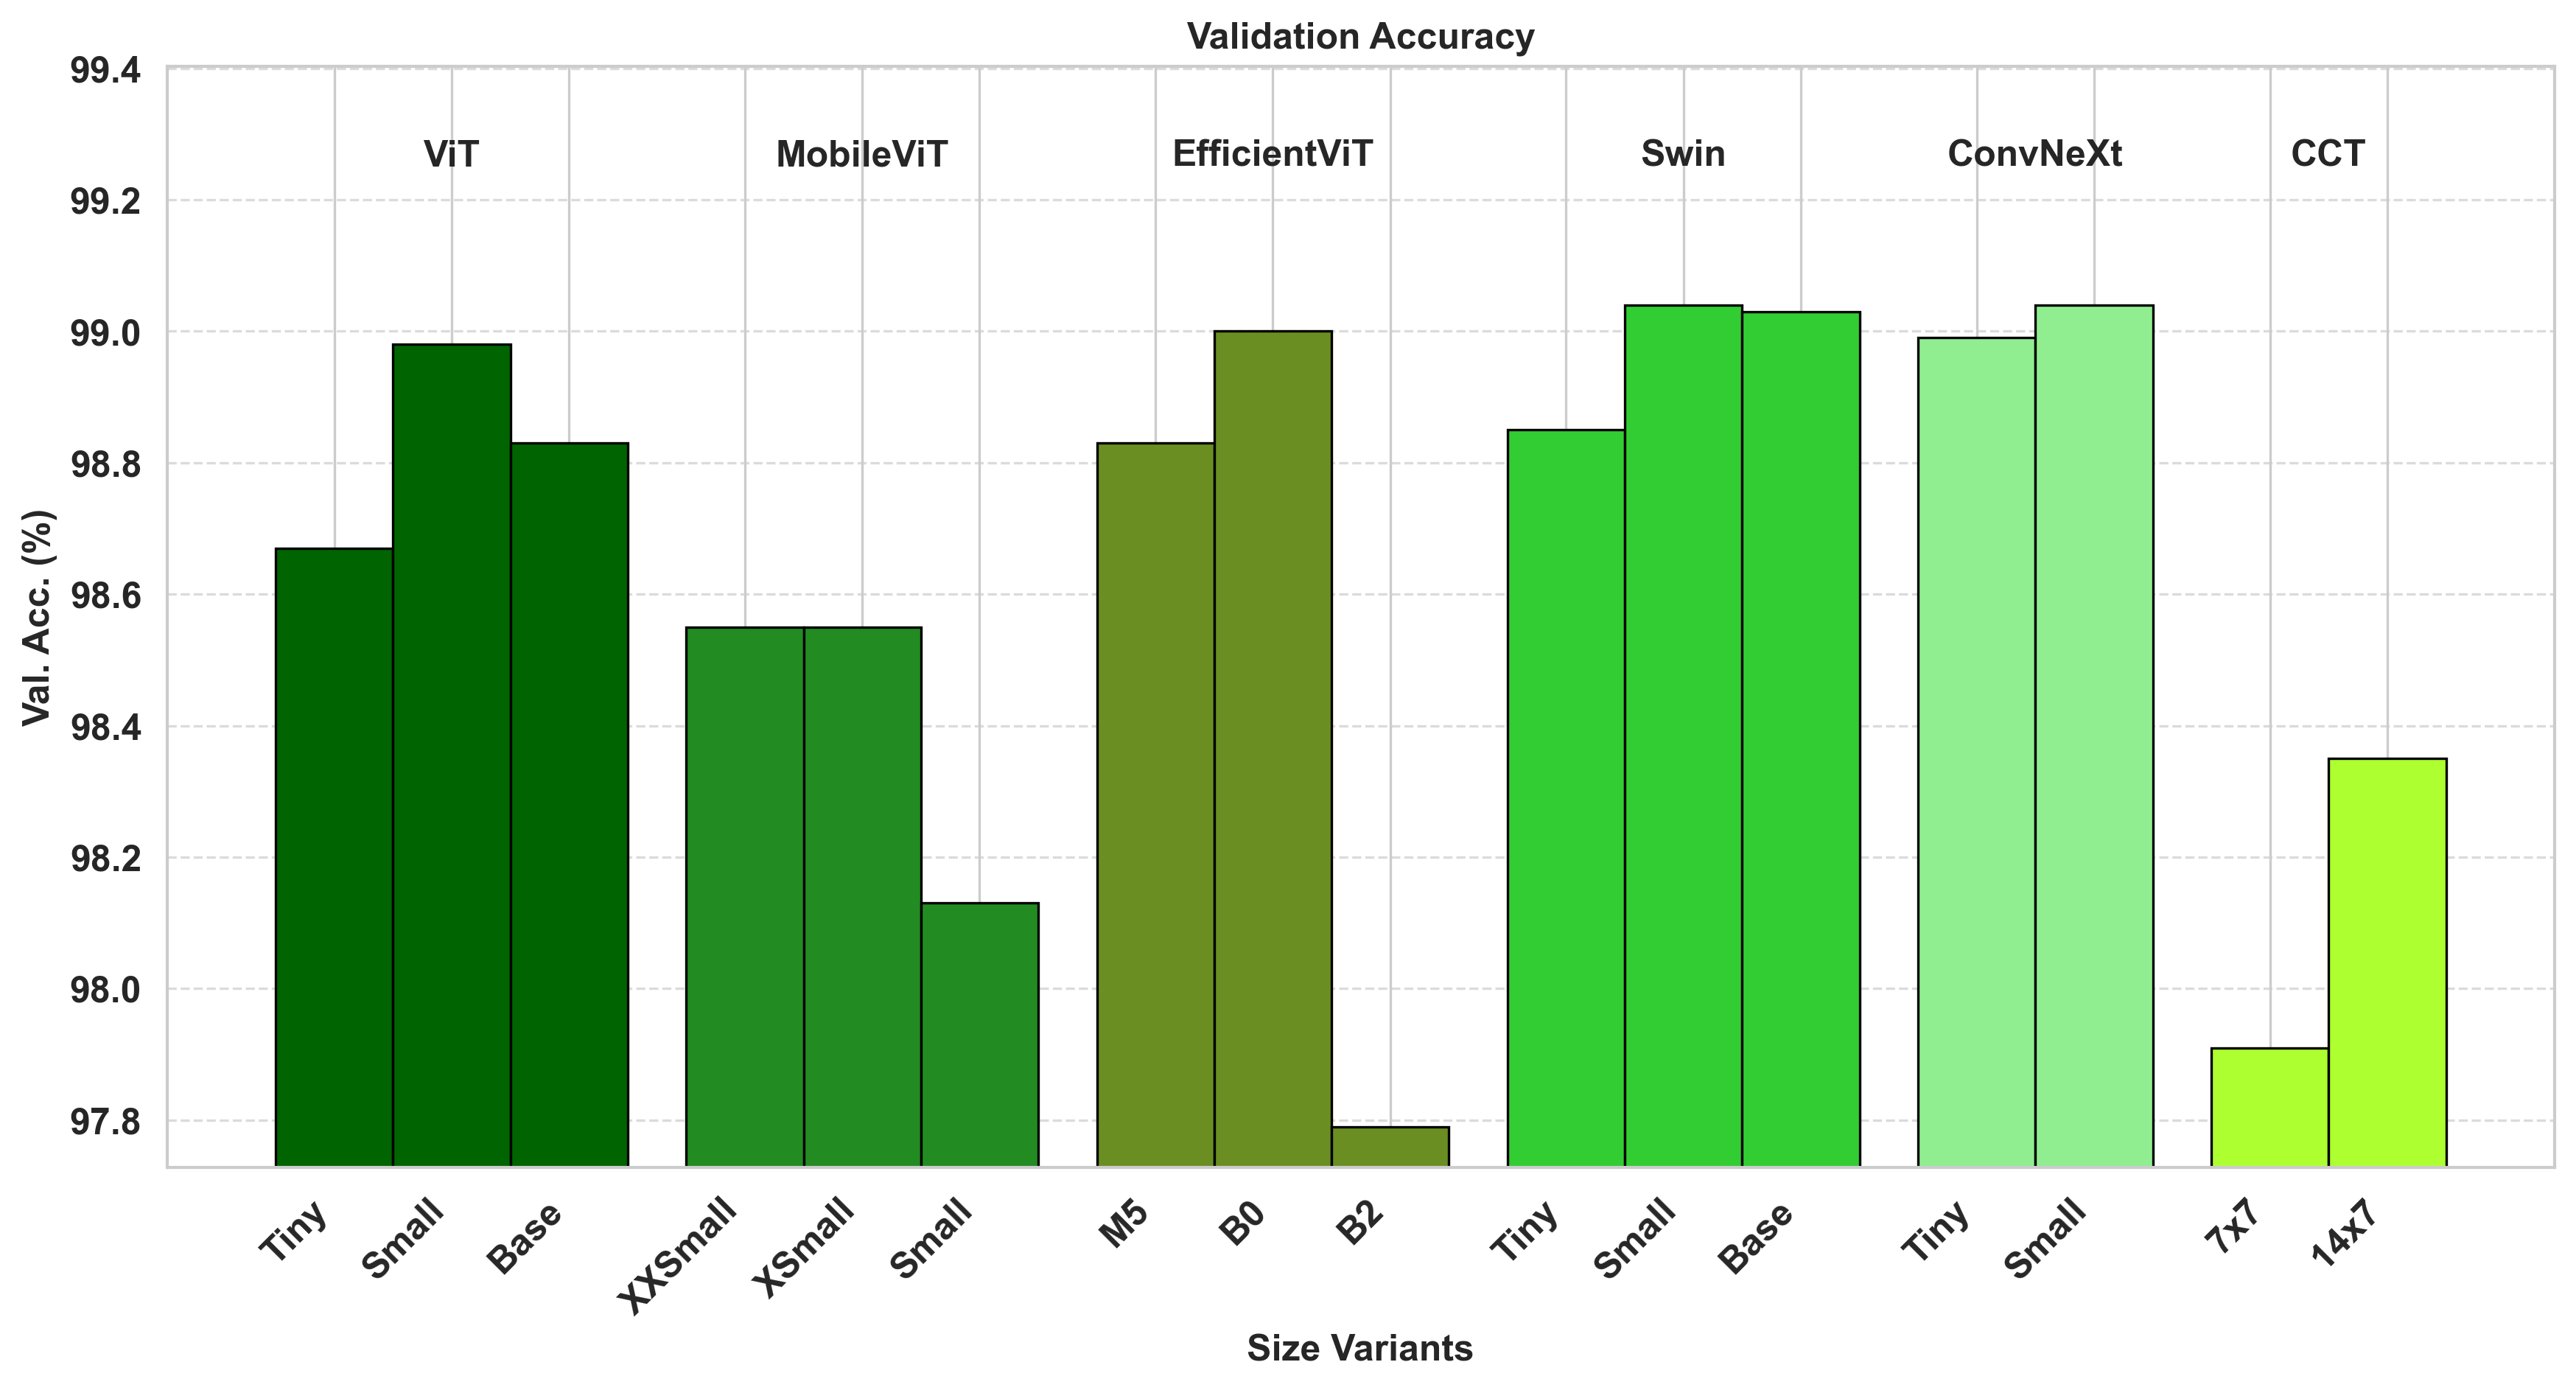

Saved plot to outputs_dataset/plots/transformer_accuracy.pdf


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from io import BytesIO
from PIL import Image

# Increase Pillow's image size limit to avoid DecompressionBombWarning
Image.MAX_IMAGE_PIXELS = 200000000

# Data from LaTeX table
models = [
    "ViT-Tiny", "ViT-Small", "ViT-Base",
    "MobileViT-XXSmall", "MobileViT-XSmall", "MobileViT-Small",
    "EfficientViT-M5", "EfficientViT-B0", "EfficientViT-B2",
    "Swin-Tiny", "Swin-Small", "Swin-Base",
    "ConvNeXt-Tiny", "ConvNeXt-Small",
    "CCT-7x7x2x224", "CCT-14x7x2x224"
]
val_accuracy = [98.67, 98.98, 98.83, 98.55, 98.55, 98.13, 98.83, 99.00, 97.79, 98.85, 99.04, 99.03, 98.99, 99.04, 97.91, 98.35]
variants = [
    "ViT", "ViT", "ViT",
    "MobileViT", "MobileViT", "MobileViT",
    "EfficientViT", "EfficientViT", "EfficientViT",
    "Swin", "Swin", "Swin",
    "ConvNeXt", "ConvNeXt",
    "CCT", "CCT"
]
sizes = [
    "Tiny", "Small", "Base",
    "XXSmall", "XSmall", "Small",
    "M5", "B0", "B2",
    "Tiny", "Small", "Base",
    "Tiny", "Small",
    "7x7", "14x7"
]

# Define green shades for each variant
variant_colors = {
    "ViT": "#006400",
    "MobileViT": "#228B22",
    "EfficientViT": "#6B8E23",
    "Swin": "#32CD32",
    "ConvNeXt": "#90EE90",
    "CCT": "#ADFF2F"
}

# Group models by variant and calculate x-positions
x_positions = []
current_pos = 0
group_gap = 0.1
bar_width = 0.2
variant_groups = {}
group_centers = []
for model, variant in zip(models, variants):
    if variant not in variant_groups:
        variant_groups[variant] = []
    variant_groups[variant].append(model)

for variant in variant_groups:
    num_models = len(variant_groups[variant])
    group_start = current_pos
    for i in range(num_models):
        x_positions.append(current_pos + i * bar_width)
    group_end = current_pos + (num_models - 1) * bar_width
    group_centers.append((group_start + group_end) / 2)
    current_pos += num_models * bar_width + group_gap

# Set Seaborn style
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.4)

# Create bar plot
plt.figure(figsize=(12, 6), dpi=300)
bars = plt.bar(x_positions, val_accuracy, width=bar_width, color=[variant_colors[variant] for variant in variants], edgecolor="black")

# Add model names above variant groups
for variant, center in zip(variant_groups.keys(), group_centers):
    plt.text(center, max(val_accuracy) + 0.2, variant,
             ha="center", va="bottom", fontsize=12, fontweight='bold')

# Customize plot
plt.xlabel("Size Variants", fontsize=12, fontweight='bold')
plt.ylabel("Val. Acc. (%)", fontsize=12, fontweight='bold')
plt.title("Validation Accuracy", fontsize=12, fontweight='bold')

# Set x-axis ticks to size variants
plt.xticks(x_positions, sizes, rotation=45, ha="right", fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')

# Set y-axis range with margin
min_acc = min(val_accuracy)
max_acc = max(val_accuracy)
margin = (max_acc - min_acc) * 0.05
plt.ylim(min_acc - margin, max_acc + margin + 0.3)
plt.grid(True, axis="y", linestyle="--", alpha=0.7)

# Adjust margins to minimize whitespace
plt.subplots_adjust(bottom=0.15, top=0.98, left=0.05, right=0.95)

# Save plot to a BytesIO buffer as PNG
buf = BytesIO()
plt.savefig(buf, format='png', dpi=300, bbox_inches='tight', pad_inches=0)
buf.seek(0)

# Use Pillow to convert PNG to PDF
img = Image.open(buf)
plot_path = 'outputs_dataset/plots/transformer_accuracy.pdf'
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
img.save(plot_path, format='PDF', resolution=300)
plt.show()
# Clean up
buf.close()
plt.close()
print(f"Saved plot to {plot_path}")

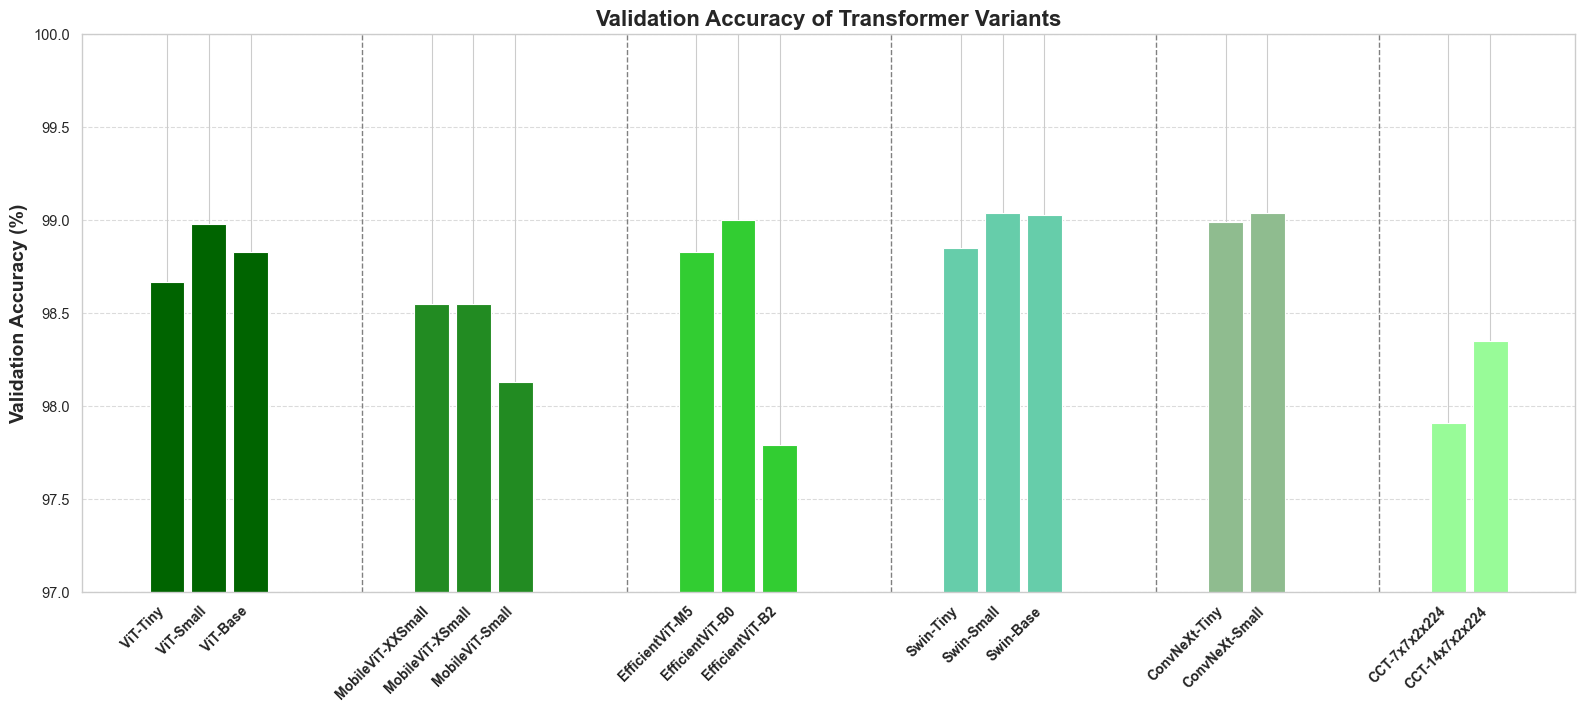

Saved plot to outputs_dataset/plots/transformer_accuracy.pdf


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from io import BytesIO
from PIL import Image
import os

# Models and Validation Accuracies
groups = {
    "ViT": [("ViT-Tiny", 98.67), ("ViT-Small", 98.98), ("ViT-Base", 98.83)],
    "MobileViT": [("MobileViT-XXSmall", 98.55), ("MobileViT-XSmall", 98.55), ("MobileViT-Small", 98.13)],
    "EfficientViT": [("EfficientViT-M5", 98.83), ("EfficientViT-B0", 99.00), ("EfficientViT-B2", 97.79)],
    "Swin": [("Swin-Tiny", 98.85), ("Swin-Small", 99.04), ("Swin-Base", 99.03)],
    "ConvNeXt": [("ConvNeXt-Tiny", 98.99), ("ConvNeXt-Small", 99.04)],
    "CCT": [("CCT-7x7x2x224", 97.91), ("CCT-14x7x2x224", 98.35)]
}

# Different shades of green (6 shades for 6 model families)
green_shades = [
    "#006400",  # ViT
    "#228B22",  # MobileViT
    "#32CD32",  # EfficientViT
    "#66CDAA",  # Swin
    "#8FBC8F",  # ConvNeXt
    "#98FB98"   # CCT
]

models = []
accuracies = []
colors = []

# Flatten data and assign colors (same color for all variants in a group)
for group_idx, (group, items) in enumerate(groups.items()):
    for model, acc in items:
        models.append(model)
        accuracies.append(acc)
        colors.append(green_shades[group_idx])

# Create positions with smaller gaps within groups and larger gaps between groups
x = []
curr_x = 0
for group in groups.values():
    for i in range(len(group)):
        x.append(curr_x)
        curr_x += 0.3
    curr_x += 1.0

# Set Seaborn style for better aesthetics
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# Plot
plt.figure(figsize=(16, 8))
bars = plt.bar(x, accuracies, color=colors, width=0.25)

# Labels and formatting
plt.xticks(x, models, rotation=45, ha='right', va='top', fontsize=10, fontweight='bold')
plt.ylabel('Validation Accuracy (%)', fontsize=14, fontweight='bold')
plt.title('Validation Accuracy of Transformer Variants', fontsize=16, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(97, 100)

# Light vertical lines between groups
group_positions = []
count = 0
for group in groups.values():
    count += len(group)
    group_positions.append(count)
group_positions = group_positions[:-1]

for pos in group_positions:
    plt.axvline(x=x[pos] - 0.5, color='gray', linestyle='--', linewidth=1)

# Adjust layout with increased bottom margin
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

# Save plot to a BytesIO buffer as PNG
buf = BytesIO()
plt.savefig(buf, format='png', dpi=300, bbox_inches='tight')
buf.seek(0)

# Use Pillow to convert PNG to PDF
img = Image.open(buf)
plot_path = 'outputs_dataset/plots/transformer_accuracy.pdf'
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
img.save(plot_path, format='PDF', resolution=300)
plt.show()
# Clean up
buf.close()
plt.close()
print(f"Saved plot to {plot_path}")

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import os
from io import BytesIO
from PIL import Image

def plot_model_parameter_sizes(include_optional_models=True):
    # Increase Pillow's image size limit to avoid DecompressionBombWarning
    Image.MAX_IMAGE_PIXELS = 200000000

    models = [
        {
            'type': 'MobileViT',
            'color': '#006400',  # Dark green
            'variants': [
                ('xx_small', 1.29),
                ('x_small', 2.29),
                ('small', 5.58)
            ]
        },
        {
            'type': 'Swin',
            'color': '#228B22',  # Forest green
            'variants': [
                ('tiny', 28.3),
                ('small', 49.6),
                ('base', 87.8)
            ]
        },
        {
            'type': 'ViT',
            'color': '#6B8E23',  # Olive green
            'variants': [
                ('tiny', 5.7),
                ('small', 21.7),
                ('base', 85.8)
            ]
        },
        {
            'type': 'ConvNeXt',
            'color': '#32CD32',  # Lime green
            'variants': [
                ('tiny', 28.6),
                ('small', 50.2),
                ('base', 88.6)
            ]
        }
    ]

    if include_optional_models:
        models.extend([
            {
                'type': 'CCT',
                'color': '#90EE90',  # Light green
                'variants': [
                    ('tiny', 3.7),
                    ('small', 6.7),
                    ('base', 13.4),
                ]
            },
            {
                'type': 'EfficientViT',
                'color': '#ADFF2F',  # Yellow-green
                'variants': [
                    ('b0', 3.4),
                    ('b2', 6.1),
                    ('m5', 8.5)
                ]
            },
            {
                'type': 'CSwin',
                'color': '#98FB98',  # Pale green
                'variants': [
                    ('tiny', 23.0),
                    ('small', 35.0),
                    ('base', 78.0)
                ]
            }
        ])

    # Sort variants within each model by parameter size
    for model in models:
        model['variants'].sort(key=lambda x: x[1])

    model_names = []
    param_sizes = []
    colors = []
    positions = []
    group_positions = []
    current_pos = 0
    bar_width = 0.15
    group_gap = 0.3  # Reduced from 0.6 to tighten spacing

    xtick_labels = []

    for model in models:
        num_variants = len(model['variants'])
        start_pos = current_pos + bar_width * num_variants / 2.0 - bar_width / 2.0
        group_positions.append(start_pos)
        for variant, params in model['variants']:
            model_names.append(model['type'])
            xtick_labels.append(variant.replace('_', '-'))
            param_sizes.append(params)
            colors.append(model['color'])
            positions.append(current_pos)
            current_pos += bar_width
        current_pos += group_gap

    plt.figure(figsize=(14, 8))
    bars = plt.bar(positions, param_sizes, width=bar_width, color=colors, edgecolor='black')

    plt.title('Parameter Sizes of Transformer Models', fontsize=16, pad=20)
    plt.ylabel('Parameters (Millions)', fontsize=14)
    plt.xticks(positions, xtick_labels, rotation=45, ha='right', fontsize=11, fontweight='bold')
    plt.yticks(fontsize=12)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

    # Add model group names below the x-axis
    y_min, y_max = plt.ylim()
    y_offset = y_min - 15  # Ensure visibility
    for group_pos, model in zip(group_positions, models):
        plt.text(group_pos, y_offset, model['type'],
                 ha='center', va='top', fontsize=13, fontweight='bold')

    # Adjust y-axis to accommodate model names
    plt.ylim(y_min - 20, y_max)

    plt.tight_layout()

    # Save plot to a BytesIO buffer as PNG
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=600, bbox_inches='tight', pad_inches=0)
    buf.seek(0)

    # Use Pillow to convert PNG to PDF
    img = Image.open(buf)
    output_dir = 'outputs_dataset/plots'
    os.makedirs(output_dir, exist_ok=True)
    plot_path = os.path.join(output_dir, 'parameter_counts.pdf')
    img.save(plot_path, format='PDF', resolution=600)

    # Clean up
    buf.close()
    plt.close()
    print(f"Saved plot to {plot_path}")

    print("\nModel Parameter Sizes (in Millions):")
    for model in models:
        print(f"{model['type']}:")
        for variant, params in model['variants']:
            print(f"  {variant.replace('_', '-')}: {params:.2f}M")

if __name__ == "__main__":
    plot_model_parameter_sizes(include_optional_models=True)

Saved plot to outputs_dataset/plots\parameter_counts.pdf

Model Parameter Sizes (in Millions):
MobileViT:
  xx-small: 1.29M
  x-small: 2.29M
  small: 5.58M
Swin:
  tiny: 28.30M
  small: 49.60M
  base: 87.80M
ViT:
  tiny: 5.70M
  small: 21.70M
  base: 85.80M
ConvNeXt:
  tiny: 28.60M
  small: 50.20M
  base: 88.60M
CCT:
  tiny: 3.70M
  small: 6.70M
  base: 13.40M
EfficientViT:
  b0: 3.40M
  b2: 6.10M
  m5: 8.50M
CSwin:
  tiny: 23.00M
  small: 35.00M
  base: 78.00M


Processing ConvNeXt-Small...


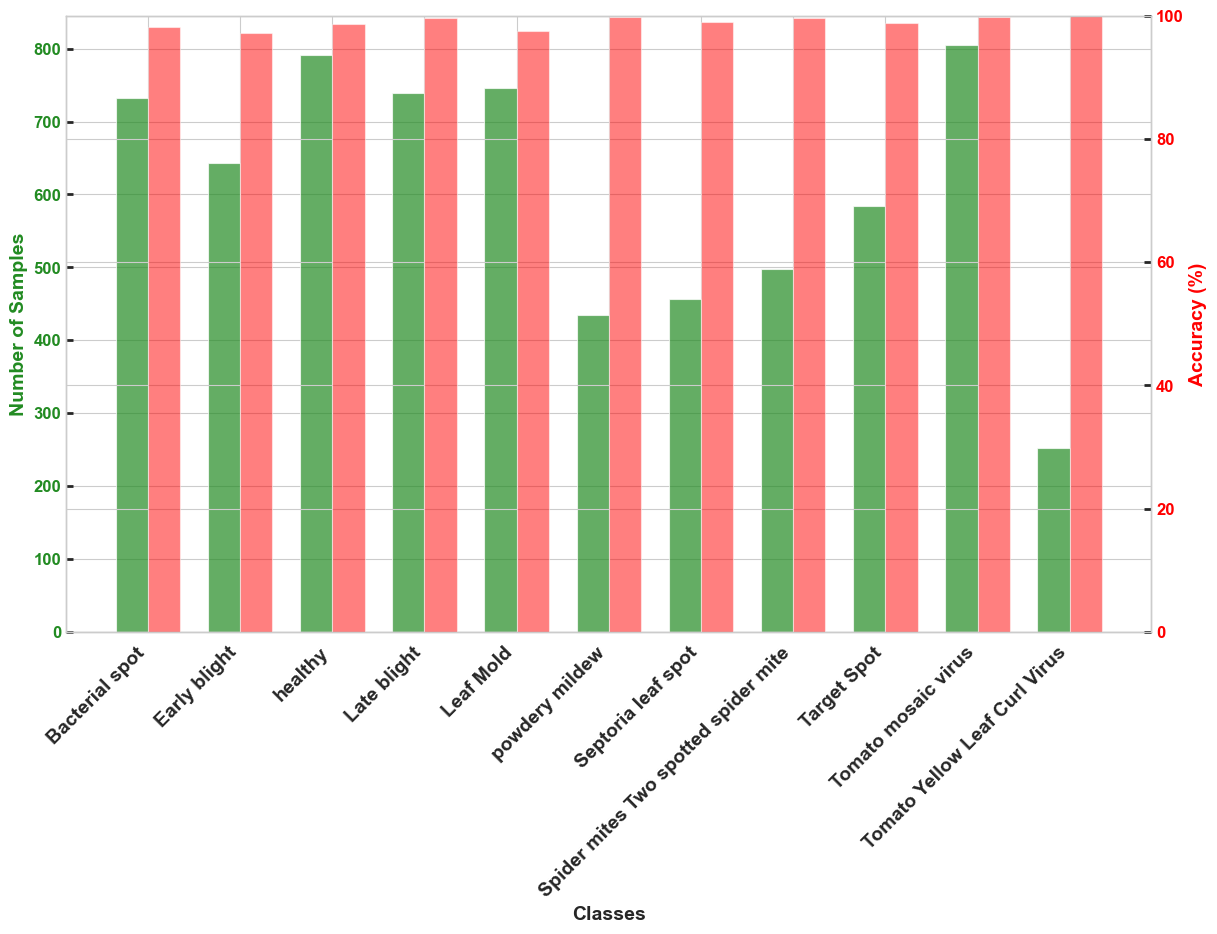

Saved plot to outputs_test\plots\classwise_accuracy_convnext_small.pdf

Class-wise Accuracies for ConvNeXt-Small:
Bacterial spot: 98.22%
Early blight: 97.20%
healthy: 98.61%
Late blight: 99.59%
Leaf Mold: 97.45%
powdery mildew: 99.77%
Septoria leaf spot: 98.91%
Spider mites Two spotted spider mite: 99.60%
Target Spot: 98.80%
Tomato mosaic virus: 99.75%
Tomato Yellow Leaf Curl Virus: 100.00%


In [30]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from io import BytesIO
from PIL import Image

def plot_classwise_accuracy(csv_path, output_dir, class_names):
    """
    Read the confusion matrix CSV for ConvNeXt-Small, compute class-wise accuracy and sample counts,
    and plot histograms with samples (green, left Y-axis) and accuracy (red, right Y-axis).
    Save the plot as a high-quality PDF using Pillow.

    Args:
        csv_path (str): Path to the confusion matrix CSV.
        output_dir (str): Directory to save the plot.
        class_names (list): List of class names with underscores replaced by spaces.
    """
    # Check if CSV exists
    if not os.path.exists(csv_path):
        print(f"Error: CSV file {csv_path} not found")
        return

    # Read CSV
    try:
        cm_df = pd.read_csv(csv_path, index_col='True Label')
    except Exception as e:
        print(f"Error reading {csv_path}: {e}")
        return

    # Validate dimensions
    if cm_df.shape != (11, 11):
        print(f"Error: Expected 11x11 matrix in {csv_path}, got {cm_df.shape}")
        return

    # Convert to numpy array
    cm = cm_df.to_numpy()

    # Compute class-wise accuracy: (diagonal / row sum) * 100
    row_sums = cm.sum(axis=1)
    accuracies = np.zeros(len(class_names))
    for i in range(len(class_names)):
        accuracies[i] = (cm[i, i] / row_sums[i] * 100) if row_sums[i] > 0 else 0.0

    # Get number of samples per class (row sums)
    samples = row_sums

    # Create plot
    fig, ax1 = plt.subplots(figsize=(14, 8))

    # Plot histogram for samples (left Y-axis, green)
    x = np.arange(len(class_names))
    bar_width = 0.35  # Width of each bar
    ax1.bar(x - bar_width / 2, samples, bar_width, color='forestgreen', alpha=0.7)
    ax1.set_xlabel('Classes', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of Samples', fontsize=14, fontweight='bold', color='forestgreen')
    ax1.tick_params(axis='y', labelcolor='forestgreen', labelsize=12, width=2, labelright=False, labelleft=True,
                    which='both', direction='in')
    ax1.tick_params(axis='x', labelsize=14, width=2)
    ax1.set_xticks(x)
    ax1.set_xticklabels(class_names, rotation=45, ha='right', fontsize=14, fontweight='bold')
    for label in ax1.get_yticklabels():
        label.set_fontweight('bold')

    # Create second Y-axis for accuracy
    ax2 = ax1.twinx()
    ax2.bar(x + bar_width / 2, accuracies, bar_width, color='red', alpha=0.5)
    ax2.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold', color='red')
    ax2.tick_params(axis='y', labelcolor='red', labelsize=12, width=2, labelleft=False, labelright=True, which='both',
                    direction='in')
    ax2.set_ylim(0, 100)
    for label in ax2.get_yticklabels():
        label.set_fontweight('bold')

    # Save plot to a BytesIO buffer as PNG
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=600, bbox_inches='tight')
    buf.seek(0)

    # Use Pillow to convert PNG to PDF
    img = Image.open(buf)
    plots_dir = os.path.join(output_dir, 'plots')
    os.makedirs(plots_dir, exist_ok=True)
    output_path = os.path.join(plots_dir, 'classwise_accuracy_convnext_small.pdf')
    img.save(output_path, format='PDF', resolution=600)
    plt.show()
    # Clean up
    buf.close()
    plt.close()
    print(f"Saved plot to {output_path}")

    # Print class-wise accuracies
    print("\nClass-wise Accuracies for ConvNeXt-Small:")
    for cls, acc in zip(class_names, accuracies):
        print(f"{cls}: {acc:.2f}%")

def main():
    output_dir = 'outputs_test'
    summaries_dir = os.path.join(output_dir, 'summaries')
    csv_path = os.path.join(summaries_dir, 'confusion_matrix_convnext_small.csv')

    # Class names with underscores replaced by spaces
    class_names = [
        "Bacterial spot", "Early blight", "healthy", "Late blight", "Leaf Mold",
        "powdery mildew", "Septoria leaf spot", "Spider mites Two spotted spider mite",
        "Target Spot", "Tomato mosaic virus", "Tomato Yellow Leaf Curl Virus"
    ]

    print("Processing ConvNeXt-Small...")
    plot_classwise_accuracy(csv_path, output_dir, class_names)

if __name__ == "__main__":
    main()

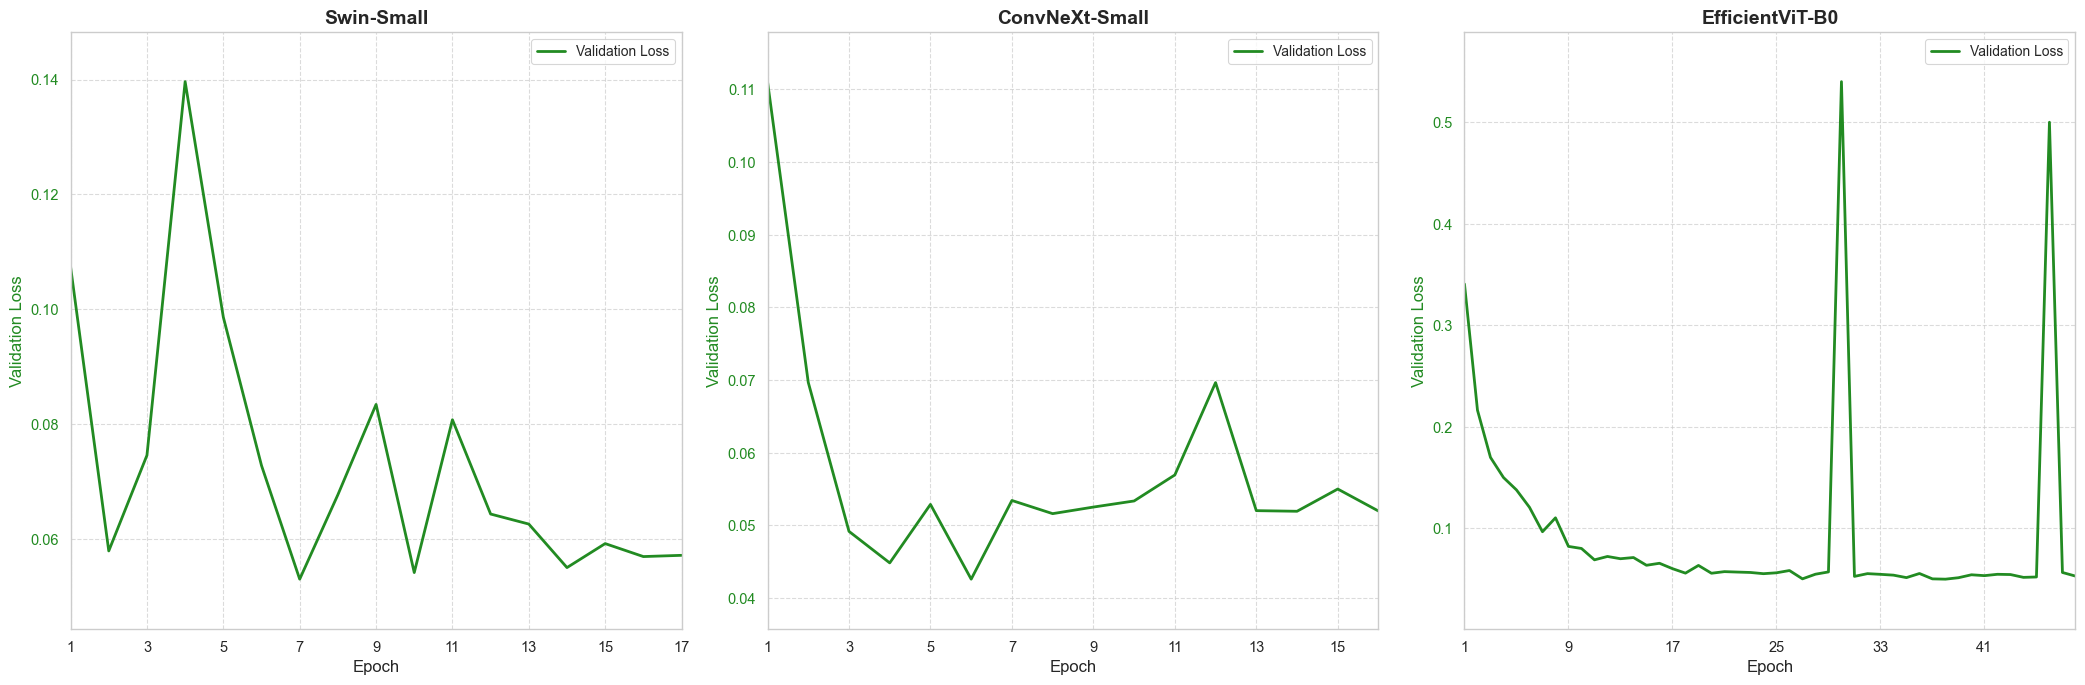

Saved plot to outputs_dataset/plots/loss_curves.pdf


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from PIL import Image
import os
import numpy as np

# Create CSV files from provided data (replace with your actual CSV files)
data_dir = 'data'
os.makedirs(data_dir, exist_ok=True)

# Swin-Small CSV
swin_small_data = pd.DataFrame({
    'epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
    'train_loss': [0.23242843281797643, 0.047450136158892646, 0.03428449384539977, 0.022570635846495546,
                   0.024886373953634324,
                   0.019634729616711814, 0.02176926495852426, 0.014848686750726628, 0.016344547934023065,
                   0.013632311120336912,
                   0.006502919660664698, 0.022933380810902723, 0.01199805334737967, 0.01130952401535514,
                   0.012332792606783483,
                   0.012989608194127238, 0.010770878692862544],
    'train_accuracy': [92.25085112968121, 98.48731043020737, 98.98638192510059, 99.2455896007428, 99.16434540389972,
                       99.36939028164655, 99.31522748375116, 99.55509130300217, 99.52800990405447, 99.54348498916744,
                       99.80269266480965, 99.30748994119467, 99.62859795728876, 99.64794181367998, 99.60538532961931,
                       99.58217270194986, 99.65181058495821],
    'train_precision': [0.9224052283765564, 0.9848766051806581, 0.9898637718120704, 0.9924565549597769,
                        0.9916490002960118,
                        0.9936954822733216, 0.9931506124257843, 0.9955525872612813, 0.9952810594939179,
                        0.9954350347954171,
                        0.9980269228766627, 0.9930748706216111, 0.9962863829711003, 0.9964797728990062,
                        0.9960538643745261,
                        0.9958212606760989, 0.9965188250857532],
    'train_recall': [0.9225085112968121, 0.9848731043020736, 0.9898638192510059, 0.992455896007428, 0.9916434540389972,
                     0.9936939028164655, 0.9931522748375116, 0.9955509130300216, 0.9952800990405447, 0.9954348498916744,
                     0.9980269266480966, 0.9930748994119468, 0.9962859795728877, 0.9964794181367997, 0.9960538532961931,
                     0.9958217270194986, 0.9965181058495822],
    'train_f1': [0.9224339983759818, 0.9848739359381677, 0.9898632643526062, 0.9924559977576576, 0.9916453809357894,
                 0.9936942560853071, 0.9931510764620424, 0.9955515764255467, 0.9952803978122439, 0.9954346372671149,
                 0.9980267249201892, 0.9930745088088208, 0.9962860542081418, 0.9964795522409555, 0.996053790077238,
                 0.9958210300639312, 0.9965183823141202],
    'val_loss': [0.10740582861406076, 0.057977944494432866, 0.07462022851696332, 0.13963225210026564,
                 0.09865771790660294,
                 0.07283500248307798, 0.05306455773271565, 0.06775324843686574, 0.08346537299255176,
                 0.054211682457095914,
                 0.08080305566595222, 0.06439707861338806, 0.06265265889255275, 0.05507968638764396,
                 0.059253809505436524,
                 0.05699612712690408, 0.05721235462431922],
    'val_accuracy': [96.91755199760587, 98.3540326200808, 97.87520574592249, 95.87011821038456, 97.57593894957354,
                     98.26425258117612, 98.86278617387401, 98.33906928026336, 97.92009576537482, 99.04234625168337,
                     97.92009576537482, 98.36899595989824, 98.3839592997157, 98.71315277569954, 98.42884931916804,
                     98.57848271734251, 98.95256621277869],
    'val_precision': [0.9706299287315742, 0.9836484620921918, 0.9794424221521371, 0.9655261074343158, 0.976657941894664,
                      0.9829364278952624, 0.9886388282137245, 0.9836500422670833, 0.9794312462067829,
                      0.9904581719025588,
                      0.9799378098396335, 0.9838841397176643, 0.9840871289389336, 0.9871534641588533,
                      0.9843063235978337,
                      0.9858658985428222, 0.9895654792905801],
    'val_recall': [0.9691755199760587, 0.983540326200808, 0.9787520574592249, 0.9587011821038456, 0.9757593894957355,
                   0.9826425258117611, 0.9886278617387401, 0.9833906928026336, 0.9792009576537484, 0.9904234625168338,
                   0.9792009576537484, 0.9836899595989825, 0.983839592997157, 0.9871315277569953, 0.9842884931916804,
                   0.9857848271734251, 0.9895256621277869],
    'val_f1': [0.9691410000533983, 0.9835432412916626, 0.9787660358600117, 0.9594639000015877, 0.9758395335762251,
               0.9826871359805834, 0.988623094850855, 0.983418956355304, 0.9791589074474492, 0.9904198213183724,
               0.9792747535519088, 0.9837136186098753, 0.9838393949669413, 0.9871200687766853, 0.9842716493798799,
               0.9858006502950167, 0.9895310694407919]
})
swin_small_data.to_csv(os.path.join(data_dir, 'swin_small_history.csv'), index=False)

# ConvNeXt-Small CSV
convnext_small_data = pd.DataFrame({
    'epoch': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
    'train_loss': [0.42720081550174366, 0.08635459741977015, 0.048003871208091395, 0.030217129170519327,
                   0.025860667862947852,
                   0.01871443169121364, 0.01736105831043026, 0.0158466824478665, 0.012444921086067928,
                   0.012484762451048983,
                   0.010919299977422593, 0.010482237019581321, 0.009167937898092726, 0.010585131610599435,
                   0.008441310117613243,
                   0.0100479928324704],
    'train_accuracy': [86.76880222841226, 97.28799133395233, 98.545341999381, 99.1720829464562, 99.22624574435159,
                       99.45450324976787, 99.45450324976787, 99.52414113277624, 99.57056638811514, 99.62472918601053,
                       99.67889198390591, 99.67889198390591, 99.72531723924482, 99.66728567007118, 99.70984215413185,
                       99.6866295264624],
    'train_precision': [0.8688333280312853, 0.9729352376834143, 0.9854666441281178, 0.9917242253009275,
                        0.9922621657950313,
                        0.9945477003841605, 0.9945486902912056, 0.9952412033857841, 0.9957065695708683,
                        0.9962473454479999,
                        0.9967913026252688, 0.9967889405210648, 0.9972537930498017, 0.9966734010522598,
                        0.9970981568885177,
                        0.99686718099585],
    'train_recall': [0.8676880222841226, 0.9728799133395234, 0.98545341999381, 0.9917208294645621, 0.9922624574435159,
                     0.9945450324976788, 0.9945450324976788, 0.9952414113277623, 0.9957056638811513, 0.9962472918601052,
                     0.9967889198390592, 0.9967889198390592, 0.9972531723924482, 0.9966728567007118, 0.9970984215413184,
                     0.996866295264624],
    'train_f1': [0.8674772703994625, 0.9728927654946504, 0.9854561089666775, 0.9917209599202306, 0.9922612791550678,
                 0.9945449867633944, 0.9945457776795067, 0.9952410706249545, 0.9957058922721165, 0.996247202727404,
                 0.996789228070344, 0.996788784236916, 0.997253214021415, 0.9966727749146539, 0.9970981873439707,
                 0.9968664431706087],
    'val_loss': [0.11107608950866205, 0.06968350212095152, 0.04917615944165219, 0.04483402779150915,
                 0.05288820129288839,
                 0.04259660279294134, 0.05342722336394918, 0.05161468220825895, 0.05252003827752662,
                 0.05335966073383099,
                 0.05694060371833621, 0.06965509038375832, 0.052026579397879615, 0.05194178023294921,
                 0.055003824912471556,
                 0.051973290680494014],
    'val_accuracy': [96.31901840490798, 97.66571898847823, 98.54855603770761, 98.75804279515188, 98.66826275624719,
                     98.98249289241359, 98.80293281460422, 98.74307945533442, 98.75804279515188, 98.87774951369146,
                     98.86278617387401, 98.42884931916804, 98.90767619332635, 99.04234625168337, 98.99745623223103,
                     99.04234625168337],
    'val_precision': [0.963921507489141, 0.9769514977410798, 0.9856094814983904, 0.9876672682250704, 0.9867182023905161,
                      0.98985832206086, 0.9881880994317872, 0.9875018554859725, 0.9875743317650997, 0.9888398565772877,
                      0.9887513067655858, 0.9845734121553372, 0.9891217930598648, 0.9904292863400962,
                      0.9899916768530991,
                      0.9904287002303708],
    'val_recall': [0.9631901840490797, 0.9766571898847822, 0.9854855603770761, 0.9875804279515188, 0.9866826275624719,
                   0.9898249289241359, 0.9880293281460422, 0.9874307945533443, 0.9875804279515188, 0.9887774951369146,
                   0.9886278617387401, 0.9842884931916804, 0.9890767619332635, 0.9904234625168338, 0.9899745623223103,
                   0.9904234625168338],
    'val_f1': [0.9631166897428167, 0.9766897687207725, 0.9854987487187128, 0.9875804005991858, 0.9866489346254472,
               0.9898193879766635, 0.9880525959906584, 0.9874276655995347, 0.9875654909344952, 0.988784472378297,
               0.9886365662692844, 0.984295042101927, 0.9890825246922755, 0.9904142692078277, 0.9899639494140534,
               0.9904151801404116]
})
convnext_small_data.to_csv(os.path.join(data_dir, 'convnext_small_history.csv'), index=False)

# EfficientViT-B0 CSV
efficientvit_b0_data = pd.DataFrame({
    'epoch': list(range(1, 49)),
    'train_loss': [0.9718228928705591, 0.4494607514067354, 0.34189018556408307, 0.283575202286225, 0.2502112752123537,
                   0.22076695003088176, 0.20139278635654756, 0.18079521766446094, 0.16605378330417994,
                   0.16003837873418425,
                   0.15225698771453872, 0.1346634899368968, 0.13227527930580843, 0.11997894021757097,
                   0.1221398410137428,
                   0.11689600613658843, 0.11252412800447965, 0.10743244375580421, 0.10210207172478364,
                   0.09761554278094346,
                   0.09322177022188229, 0.09258963370131325, 0.08746448285123654, 0.08494131964395306,
                   0.08360792059567793,
                   0.08312052940296633, 0.08136435825733974, 0.07696522316191817, 0.07576556305920734,
                   0.07325892969020488,
                   0.07577545806207513, 0.0728514625842783, 0.07185072531846978, 0.07090157171736115,
                   0.06845107774677678,
                   0.0658628621528629, 0.0654357274834566, 0.06486366531015808, 0.06334418913909283, 0.0618142592799955,
                   0.06082884088753547, 0.06299693416659952, 0.05579996959910751, 0.05951402347658264,
                   0.05354566237978875,
                   0.05857836269476362, 0.05359872066450724, 0.05629436668044308],
    'train_accuracy': [69.28582482203652, 85.10909935004642, 88.63354998452492, 90.38223460229031, 91.71309192200557,
                       92.68802228412257, 93.31089445991952, 94.03048591767255, 94.51021355617456, 94.73847106159084,
                       95.00928505106778, 95.69792633859487, 95.72500773754255, 96.04998452491489, 95.94552770040235,
                       96.16604766326215, 96.44073042401733, 96.42912411018261, 96.69220055710306, 96.86629526462396,
                       97.0171773444754, 96.99783348808418, 97.12937171154441, 97.20674713710926, 97.32281027545652,
                       97.28799133395233, 97.38471061590839, 97.53559269575983, 97.55880532342928, 97.56654286598577,
                       97.50851129681213, 97.64778706282884, 97.56654286598577, 97.64778706282884, 97.7715877437326,
                       97.85283194057567, 97.86830702568864, 97.86830702568864, 97.99597647787063, 97.96889507892294,
                       97.96115753636646, 97.87991333952337, 98.16233364283504, 98.01532033426184, 98.25905292479109,
                       98.0385329619313, 98.25131538223461, 98.17007118539152],
    'train_precision': [0.6933931698340087, 0.8510588804789055, 0.8864584614776497, 0.9038392900525738,
                        0.9173532719992138,
                        0.9269489133260171, 0.9331736348511571, 0.9403817233289562, 0.9451826699009501,
                        0.9474597202068373,
                        0.9501764280847134, 0.9570573966690109, 0.9572941897060023, 0.9605133090271777,
                        0.9594714273257917,
                        0.9616707094111249, 0.9644429914153299, 0.9642975053326689, 0.9669346278762584,
                        0.9686888103998128,
                        0.9701835344234985, 0.970000746117922, 0.9713290447881909, 0.9720932151428868,
                        0.973233360866625,
                        0.9729100634837982, 0.9738417137737251, 0.9753639528115077, 0.9756021740907037,
                        0.9756719989852508,
                        0.9750940130454719, 0.9764872701095836, 0.9756592813729055, 0.9764926630454378,
                        0.9777241724009296,
                        0.9785335787428444, 0.9786839650229757, 0.9786913255997912, 0.9799659767836361,
                        0.9796875048248465,
                        0.979614138015824, 0.978809676213334, 0.9816200469113652, 0.980156105275658, 0.9826081005847195,
                        0.9803860613414445, 0.9825100088894704, 0.9816993112716694],
    'train_recall': [0.6928582482203652, 0.8510909935004642, 0.8863354998452492, 0.9038223460229031, 0.9171309192200557,
                     0.9268802228412256, 0.9331089445991952, 0.9403048591767255, 0.9451021355617456, 0.9473847106159083,
                     0.9500928505106778, 0.9569792633859486, 0.9572500773754256, 0.9604998452491489, 0.9594552770040236,
                     0.9616604766326214, 0.9644073042401733, 0.9642912411018261, 0.9669220055710307, 0.9686629526462396,
                     0.9701717734447539, 0.9699783348808418, 0.9712937171154441, 0.9720674713710925, 0.9732281027545652,
                     0.9728799133395234, 0.9738471061590839, 0.9753559269575983, 0.9755880532342928, 0.9756654286598576,
                     0.9750851129681213, 0.9764778706282885, 0.9756654286598576, 0.9764778706282885, 0.9777158774373259,
                     0.9785283194057567, 0.9786830702568864, 0.9786830702568864, 0.9799597647787063, 0.9796889507892294,
                     0.9796115753636645, 0.9787991333952337, 0.9816233364283503, 0.9801532033426184, 0.982513153822346,
                     0.9803853296193129, 0.982513153822346, 0.9817007118539152],
    'train_f1': [0.6924190751103517, 0.8509556603070525, 0.8863201691393222, 0.9037875085350312, 0.9171953279840301,
                 0.9268903342886978, 0.933110223563481, 0.9403135185488076, 0.9451172305897867, 0.9474030063136246,
                 0.9501141849861456, 0.9569975226486628, 0.9572592329315704, 0.9604923075723548, 0.9594512298550776,
                 0.9616604867696341, 0.9644117224971323, 0.9642844388367809, 0.9669196091874203, 0.9686652936420473,
                 0.970170349408859, 0.9699856812263566, 0.9713022274097552, 0.9720707781572214, 0.9732240317852238,
                 0.97288576124265, 0.9738353711070499, 0.9753527637096037, 0.9755897354939085, 0.9756641975332437,
                 0.9750839537693081, 0.9764767873654815, 0.9756599544708431, 0.9764792729368609, 0.977713507856233,
                 0.978526124161505, 0.9786809351786162, 0.978679489818877, 0.9799590746662015, 0.979687127774268,
                 0.9796099887088892, 0.9787994979685903, 0.981619164697934, 0.9801503917571973, 0.9825945951243393,
                 0.9803842786850373, 0.9825105561838596, 0.9816978835078505],
    'val_loss': [0.3405364002454393, 0.2161558542702167, 0.16960591046365636, 0.14978713514909012, 0.13754694557343344,
                 0.12041337395787292, 0.09633884238076125, 0.11004948542893299, 0.08187042667873155,
                 0.07983342478809605,
                 0.06863107382328647, 0.07196106424408301, 0.06972587911377838, 0.07091087765525399,
                 0.06327353497083879,
                 0.06525063396987679, 0.05994449649284842, 0.05553041074576045, 0.06311922244256306,
                 0.055416426079766636,
                 0.05701188819565701, 0.056577002361654284, 0.05618594698104843, 0.05498562860895591,
                 0.055860272268666425,
                 0.058099835606457165, 0.049894806708295755, 0.05446831633838318, 0.05671568896515241, 0.54,
                 0.05232848447544276,
                 0.05503457723103966, 0.05434240860299846, 0.05354665507636039, 0.05111183187997906,
                 0.05516077668371091,
                 0.04987421535921524, 0.04958483735080622, 0.051002629392044696, 0.05390478432700807,
                 0.053052763587074864,
                 0.05438181142045817, 0.054141158492606235, 0.05135907430083873, 0.05173099424504175, 0.50,
                 0.056180351957243725,
                 0.05261551798701925],
    'val_accuracy': [89.57055214723927, 93.02708364506958, 94.49349094717941, 95.13691455932964, 95.31647463713901,
                     96.25916504563818, 96.88762531797097, 96.58835852162203, 97.5310489301212, 97.60586562920844,
                     97.92009576537482, 97.78542570701781, 98.00987580427952, 97.90513242555738, 98.30914260062846,
                     98.26425258117612, 98.44381265898548, 98.62337273679485, 98.20439922190633, 98.48870267843783,
                     98.47373933862038, 98.44381265898548, 98.6383360766123, 98.47373933862038, 98.51862935807272,
                     98.59344605715995, 98.68322609606464, 98.57848271734251, 98.45877599880293, 98.50366601825527,
                     98.66826275624719, 98.54855603770761, 98.6383360766123, 98.59344605715995, 98.77300613496932,
                     98.69818943588209, 98.78796947478678, 98.81789615442166, 98.81789615442166, 98.74307945533442,
                     98.62337273679485, 98.65329941642975, 98.80293281460422, 98.78796947478678, 98.77300613496932,
                     98.78796947478678, 98.74307945533442, 98.83285949423912],
    'val_precision': [0.8964439339931819, 0.9306353153830794, 0.9449488139975385, 0.951836848961452, 0.95403976643374,
                      0.9632150119718256, 0.9690998902770306, 0.9664159309319821, 0.9754190044243066,
                      0.9761643984525412,
                      0.9791985281003712, 0.9779788268481359, 0.9801802976256814, 0.979173850206146, 0.9831567361861908,
                      0.9826766741817458, 0.9844837521826421, 0.9863206524243259, 0.9821713733833226,
                      0.9848691994474047,
                      0.9847712554099942, 0.9844891466194173, 0.98648076030858, 0.9847426661360215, 0.9852264956690674,
                      0.9859442851630918, 0.9868866473634573, 0.9857949419783623, 0.9845963124011825,
                      0.9850551955893183,
                      0.9866798066586876, 0.9854880900585105, 0.9864644690581362, 0.9859969634062621,
                      0.9877487477696745,
                      0.9869914304484844, 0.9879294206234218, 0.9882150187125681, 0.9881835994861491,
                      0.9874452769220115,
                      0.9862139491856058, 0.9865245558195016, 0.9880532063443205, 0.9878833631587174,
                      0.9877453079019135,
                      0.9878827562263731, 0.9874394644435137, 0.9883442667290598],
    'val_recall': [0.8957055214723927, 0.9302708364506957, 0.9449349094717941, 0.9513691455932964, 0.9531647463713901,
                   0.9625916504563818, 0.9688762531797097, 0.9658835852162203, 0.975310489301212, 0.9760586562920844,
                   0.9792009576537484, 0.977854257070178, 0.9800987580427951, 0.9790513242555738, 0.9830914260062846,
                   0.9826425258117611, 0.9844381265898549, 0.9862337273679486, 0.9820439922190632, 0.9848870267843782,
                   0.9847373933862038, 0.9844381265898549, 0.986383360766123, 0.9847373933862038, 0.9851862935807272,
                   0.9859344605715996, 0.9868322609606465, 0.9857848271734251, 0.9845877599880293, 0.9850366601825528,
                   0.9866826275624719, 0.9854855603770761, 0.986383360766123, 0.9859344605715996, 0.9877300613496932,
                   0.9869818943588209, 0.9878796947478677, 0.9881789615442167, 0.9881789615442167, 0.9874307945533443,
                   0.9862337273679486, 0.9865329941642975, 0.9880293281460422, 0.9878796947478677, 0.9877300613496932,
                   0.9878796947478677, 0.9874307945533443, 0.9883285949423911],
    'val_f1': [0.8947515944027462, 0.9299398934322437, 0.9448209229446863, 0.9514021950224547, 0.9528654803137622,
               0.9626402208940827, 0.9688506717078793, 0.9657813869692993, 0.9752894806787463, 0.9760237374251519,
               0.9791595473379994, 0.9778372256290775, 0.9800924334131766, 0.9790337391660224, 0.9830930719664899,
               0.9826229837684772, 0.9844299377982187, 0.9862329012100279, 0.9820502784414235, 0.9848687394873783,
               0.9847299250545305, 0.984436499399896, 0.9863823059369975, 0.9847261332131501, 0.9851822929454678,
               0.9859223034228898, 0.9868286941668436, 0.985770402480495, 0.9845522212420535, 0.9850234756377845,
               0.986664654673541, 0.9854669973636595, 0.9863863140005228, 0.9859165410082902, 0.987727550553466,
               0.9869716874143419, 0.9878793541714866, 0.9881878683201548, 0.9881740610065923, 0.9874246919368685,
               0.9862139146001796, 0.9865121655344122, 0.988027614637807, 0.9878655369427014, 0.9877218328053856,
               0.9878724668316622, 0.9874067138286035, 0.9883203632020522]
})
efficientvit_b0_data.to_csv(os.path.join(data_dir, 'efficientvit_b0_history.csv'), index=False)

# Read CSV files (update with your actual file names)
csv_files = {
    'Swin-Small': 'swin_small_history.csv',
    'ConvNeXt-Small': 'convnext_small_history.csv',
    'EfficientViT-B0': 'efficientvit_b0_history.csv'
}
datasets = {}
for model, file in csv_files.items():
    try:
        df = pd.read_csv(os.path.join(data_dir, file))
        if not all(col in df.columns for col in ['epoch', 'val_loss']):
            raise ValueError(f"Missing required columns in {file}")
        datasets[model] = df
    except Exception as e:
        print(f"Error reading {file}: {e}")
        exit(1)

# Set Seaborn style for better aesthetics
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# Create figure with three subplots in a row
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
axes = axes.flatten()

# Plot validation loss curves with model-specific y-axis ranges
for idx, (model, data) in enumerate(datasets.items()):
    ax = axes[idx]

    # Plot validation loss (forest green)
    ax.plot(data['epoch'], data['val_loss'], color='forestgreen', label='Validation Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Validation Loss', fontsize=12, color='forestgreen')
    ax.tick_params(axis='y', labelcolor='forestgreen')

    # Set x-axis ticks based on epoch count
    max_epoch = int(data['epoch'].max())
    if max_epoch > 20:  # EfficientViT-B0 has 48 epochs
        ax.set_xticks(range(1, max_epoch + 1, 8))
    else:  # Swin-Small (17), ConvNeXt-Small (16)
        ax.set_xticks(range(1, max_epoch + 1, 2))
    ax.set_xlim(1, max_epoch)

    # Set model-specific y-axis range with 10% margin
    min_loss = data['val_loss'].min()
    max_loss = data['val_loss'].max()
    margin = (max_loss - min_loss) * 0.1
    ax.set_ylim(min_loss - margin, max_loss + margin)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Title and legend
    ax.set_title(model, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')

# Adjust layout
plt.tight_layout()

# Save plot to a BytesIO buffer as PNG
buf = BytesIO()
plt.savefig(buf, format='png', dpi=300, bbox_inches='tight')
buf.seek(0)

# Use Pillow to convert PNG to PDF
img = Image.open(buf)
plot_path = 'outputs_dataset/plots/loss_curves.pdf'
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
img.save(plot_path, format='PDF', resolution=300)
plt.show()
# Clean up
buf.close()
plt.close()
print(f"Saved plot to {plot_path}")





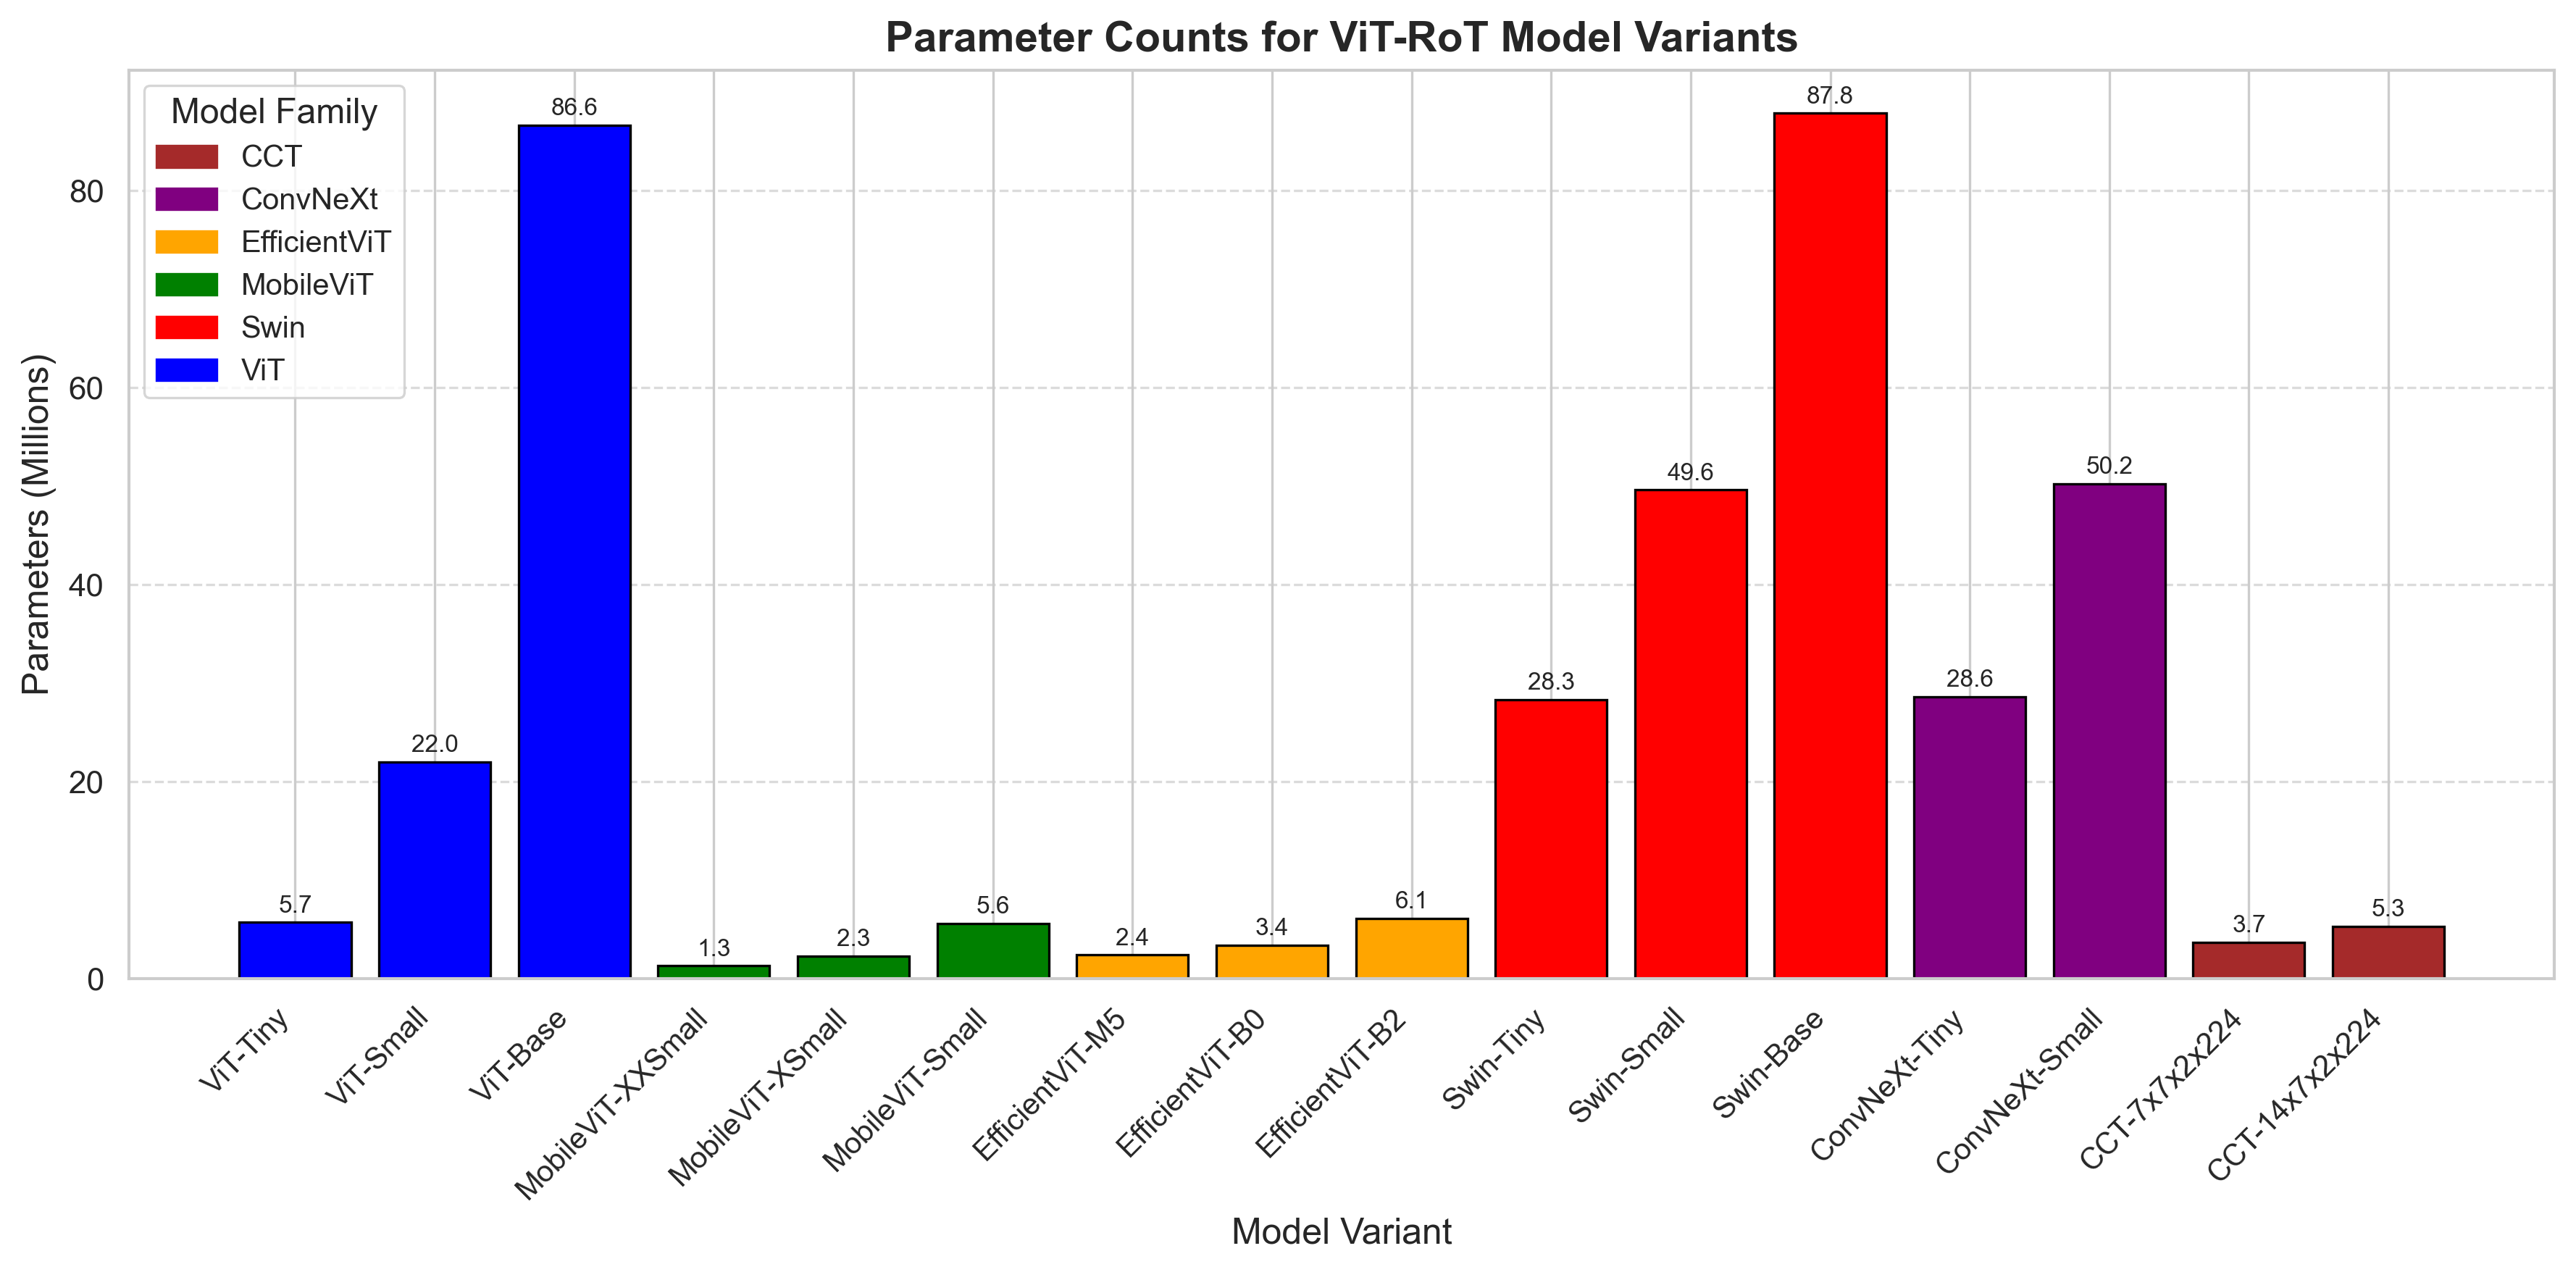

Saved plot to outputs_dataset/plots/parameter_counts.pdf


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from PIL import Image
import os
import numpy as np

# Data: Model names and parameter counts (in millions)
models = [
    "ViT-Tiny", "ViT-Small", "ViT-Base",
    "MobileViT-XXSmall", "MobileViT-XSmall", "MobileViT-Small",
    "EfficientViT-M5", "EfficientViT-B0", "EfficientViT-B2",
    "Swin-Tiny", "Swin-Small", "Swin-Base",
    "ConvNeXt-Tiny", "ConvNeXt-Small",
    "CCT-7x7x2x224", "CCT-14x7x2x224"
]
parameters = [5.7, 22.0, 86.6, 1.3, 2.3, 5.6, 2.4, 3.4, 6.1, 28.3, 49.6, 87.8, 28.6, 50.2, 3.7, 5.3]

# Model families for color coding
families = [
    "ViT", "ViT", "ViT",
    "MobileViT", "MobileViT", "MobileViT",
    "EfficientViT", "EfficientViT", "EfficientViT",
    "Swin", "Swin", "Swin",
    "ConvNeXt", "ConvNeXt",
    "CCT", "CCT"
]
family_colors = {
    "ViT": "blue",
    "MobileViT": "green",
    "EfficientViT": "orange",
    "Swin": "red",
    "ConvNeXt": "purple",
    "CCT": "brown"
}

# Set Seaborn style for consistency with loss curves
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# Create bar plot
plt.figure(figsize=(12, 6), dpi=300)
bars = plt.bar(models, parameters, color=[family_colors[family] for family in families], edgecolor="black")

# Annotate bars with parameter counts
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{height:.1f}",
             ha="center", va="bottom", fontsize=8)

# Customize plot
plt.xlabel("Model Variant", fontsize=12)
plt.ylabel("Parameters (Millions)", fontsize=12)
plt.title("Parameter Counts for ViT-RoT Model Variants", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.grid(True, axis="y", linestyle="--", alpha=0.7)

# Create legend for model families
handles = [plt.Rectangle((0,0),1,1, color=family_colors[family]) for family in sorted(set(families))]
plt.legend(handles, sorted(set(families)), title="Model Family", loc="upper left", fontsize=10)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Save plot to a BytesIO buffer as PNG
buf = BytesIO()
plt.savefig(buf, format='png', dpi=300, bbox_inches='tight')
buf.seek(0)

# Use Pillow to convert PNG to PDF
img = Image.open(buf)
plot_path = 'outputs_dataset/plots/parameter_counts.pdf'
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
img.save(plot_path, format='PDF', resolution=300)
plt.show()
# Clean up
buf.close()
plt.close()
print(f"Saved plot to {plot_path}")



In [34]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Define class names
class_names = [
    "Bacterial_spot",
    "Early_blight",
    "healthy",
    "Late_blight",
    "Leaf_Mold",
    "powdery_mildew",
    "Septoria_leaf_spot",
    "Spider_mites Two-spotted_spider_mite",
    "Target_Spot",
    "Tomato_mosaic_virus",
    "Tomato_Yellow_Leaf_Curl_Virus"
]

# Generate 11 unique colors using tab20 colormap
colormap = cm.get_cmap('tab20', len(class_names))
colors = [mcolors.rgb2hex(colormap(i)) for i in range(len(class_names))]


def count_images(data_dir, class_names):
    """
    Count images per class in train and val splits.
    Returns a DataFrame with train and val counts.
    """
    counts = {'train': {}, 'val': {}}
    total_images = 0
    valid_extensions = ('.jpg', '.png', '.jpeg')

    for split in ['train', 'val']:
        split_dir = os.path.join(data_dir, split)
        if not os.path.exists(split_dir):
            print(f"Error: Directory {split_dir} does not exist")
            raise FileNotFoundError(f"Directory {split_dir} does not exist")

        for class_name in class_names:
            class_path = os.path.join(split_dir, class_name)
            if not os.path.exists(class_path):
                print(f"Warning: Class directory {class_path} does not exist")
                counts[split][class_name] = 0
                continue

            image_files = [
                f for f in os.listdir(class_path)
                if f.lower().endswith(valid_extensions) and os.path.isfile(os.path.join(class_path, f))
            ]
            count = len(image_files)
            counts[split][class_name] = count
            total_images += count
            print(f"{split}/{class_name}: {count} images found")

        if not counts[split]:
            print(f"Error: No classes found in {split_dir}")
            raise ValueError(f"No classes found in {split_dir}")

    if total_images == 0:
        print("Error: No valid images found in dataset")
        raise ValueError("No valid images found in dataset")

    df = pd.DataFrame({
        'Class': class_names,
        'Train': [counts['train'][cls] for cls in class_names],
        'Val': [counts['val'][cls] for cls in class_names]
    })
    for _, row in df.iterrows():
        total = row['Train'] + row['Val']
        print(f"Total {row['Class']}: {total} images (Train: {row['Train']}, Val: {row['Val']})")
    print(f"Grand Total: {total_images} images found")
    return df


def plot_donut_train(df, class_names, output_dir, colors):
    """
    Create and save a donut chart for train split.
    """
    plt.figure(figsize=(12, 10), dpi=400)

    counts = df['Train']
    valid_indices = [i for i, count in enumerate(counts) if count > 0]
    valid_classes = [class_names[i] for i in valid_indices]
    valid_counts = [counts[i] for i in valid_indices]
    valid_colors = [colors[i] for i in valid_indices]

    if not valid_counts:
        print("Error: No valid counts to plot for train")
        return

    wedges, texts = plt.pie(
        valid_counts,
        labels=[str(count) for count in valid_counts],
        autopct=None,
        startangle=90,
        textprops={'fontsize': 20},
        wedgeprops={'width': 0.4},
        colors=valid_colors
    )

    plt.title('Class Distribution: Train Split [Donut]', fontsize=16, pad=20)
    plt.tight_layout()

    plot_path = os.path.join(output_dir, 'plots', 'class_distribution_donut_train.png')
    os.makedirs(os.path.dirname(plot_path), exist_ok=True)
    plt.savefig(plot_path, dpi=400, bbox_inches='tight')
    print(f"Saved train donut chart to {plot_path}")
    plt.close()


def plot_donut_val(df, class_names, output_dir, colors):
    """
    Create and save a donut chart for val split.
    """
    plt.figure(figsize=(12, 10), dpi=400)

    counts = df['Val']
    valid_indices = [i for i, count in enumerate(counts) if count > 0]
    valid_classes = [class_names[i] for i in valid_indices]
    valid_counts = [counts[i] for i in valid_indices]
    valid_colors = [colors[i] for i in valid_indices]

    if not valid_counts:
        print("Error: No valid counts to plot for val")
        return

    wedges, texts = plt.pie(
        valid_counts,
        labels=[str(count) for count in valid_counts],
        autopct=None,
        startangle=90,
        textprops={'fontsize': 20},
        wedgeprops={'width': 0.4},
        colors=valid_colors
    )

    plt.title('Class Distribution: Validation Split [Donut]', fontsize=16, pad=20)
    plt.tight_layout()

    plot_path = os.path.join(output_dir, 'plots', 'class_distribution_donut_val.png')
    os.makedirs(os.path.dirname(plot_path), exist_ok=True)
    plt.savefig(plot_path, dpi=400, bbox_inches='tight')
    print(f"Saved val donut chart to {plot_path}")
    plt.close()


def main():
    data_dir = 'dataset/tomato_leaf_dataset'
    output_dir = 'outputs_dataset'

    try:
        df = count_images(data_dir, class_names)

        # Save dataset distribution to CSV
        summaries_dir = os.path.join(output_dir, 'summaries')
        os.makedirs(summaries_dir, exist_ok=True)
        csv_path = os.path.join(summaries_dir, 'dataset_distribution.csv')
        df.to_csv(csv_path, index=False)
        print(f"Saved dataset distribution to {csv_path}")

        plot_donut_train(df, class_names, output_dir, colors)
        plot_donut_val(df, class_names, output_dir, colors)
    except Exception as e:
        print(f"Error: {e}")


if __name__ == '__main__':
    main()

C:\Users\nisha\AppData\Local\Temp\ipykernel_50480\2426964325.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab20', len(class_names))


train/Bacterial_spot: 2826 images found
train/Early_blight: 2455 images found
train/healthy: 3051 images found
train/Late_blight: 3113 images found
train/Leaf_Mold: 2754 images found
train/powdery_mildew: 1004 images found
train/Septoria_leaf_spot: 2882 images found
train/Spider_mites Two-spotted_spider_mite: 1747 images found
train/Target_Spot: 1827 images found
train/Tomato_mosaic_virus: 2153 images found
train/Tomato_Yellow_Leaf_Curl_Virus: 2036 images found
val/Bacterial_spot: 732 images found
val/Early_blight: 643 images found
val/healthy: 805 images found
val/Late_blight: 792 images found
val/Leaf_Mold: 739 images found
val/powdery_mildew: 252 images found
val/Septoria_leaf_spot: 746 images found
val/Spider_mites Two-spotted_spider_mite: 435 images found
val/Target_Spot: 457 images found
val/Tomato_mosaic_virus: 584 images found
val/Tomato_Yellow_Leaf_Curl_Virus: 498 images found
Total Bacterial_spot: 3558 images (Train: 2826, Val: 732)
Total Early_blight: 3098 images (Train: 245